# 🏠 House Price Prediction
### train Data House Price| Kaggle Competition
**Author:** Sunil Kumar | MSc AI & ML — IIIT Lucknow
**Stack:** Python · Pandas · Scikit-learn · Linear Regression · Random Forest · XGBoost
**Objective:** Predict house sale prices using regression models with hyperparameter tuning.

---
## 📋 Project Flow
1. Libraries & Setup
2. Load Data & EDA
3. Missing Value Treatment
4. Outlier Removal
5. Feature Engineering
6. Encoding
7. Train-Test Split & Scaling
8. Baseline Models
9. Hyperparameter Tuning
10. Final Results & Model Saving

# Libraries
 1. Import NumPy for numerical computations (array ops, stats
    calculations)

 2. Import Pandas to "load, clean, and manipulate the House Price dataset"

 3. import matplotlib to visualise data and understand EDA part

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

# display settings
pd.set_option("display.max_columns", None)

import sys
import os

sys.path.append(os.path.abspath(".."))

In [9]:
# Create folder to save all plots
os.makedirs("plots", exist_ok=True)

# Understanding the Dataset

In [10]:
df = pd.read_csv(r'C:\Users\kumar\OneDrive\Documents\house-price-predicition\data\train Data House Price.csv')

In [11]:
(df.sample(10))

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
772,773,80,RL,94.0,7819,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,SLvl,6,5,1976,1976,Gable,CompShg,Plywood,Plywood,NaN,0.0,TA,TA,CBlock,TA,TA,Av,ALQ,422,BLQ,127,480,1029,GasA,TA,Y,SBrkr,1117,0,0,1117,1,0,1,0,3,1,TA,6,Typ,1,TA,Detchd,1976.0,Unf,2,672,TA,TA,Y,144,0,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Abnorml,107000
190,191,70,RL,70.0,10570,Pave,NaN,Reg,Bnk,AllPub,Inside,Mod,Crawfor,Norm,Norm,1Fam,2Story,8,8,1932,1994,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,Gd,Gd,No,Rec,297,Unf,0,556,853,GasA,TA,Y,SBrkr,1549,1178,0,2727,0,0,2,1,3,1,Gd,10,Maj1,2,TA,Detchd,1932.0,Unf,2,440,TA,TA,Y,0,74,0,0,0,0,NaN,NaN,NaN,0,12,2007,WD,Normal,315000
1158,1159,20,RL,92.0,11932,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Somerst,Feedr,Norm,1Fam,1Story,8,5,2007,2008,Gable,CompShg,VinylSd,VinylSd,Stone,186.0,Gd,TA,PConc,Gd,TA,No,Unf,0,Unf,0,1580,1580,GasA,Ex,Y,SBrkr,1580,0,0,1580,0,0,2,0,3,1,Gd,7,Typ,0,NaN,Attchd,2008.0,RFn,3,830,TA,TA,Y,0,24,0,0,0,0,NaN,NaN,NaN,0,6,2008,ConLD,Partial,235128
677,678,30,RL,52.0,9022,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Norm,Norm,1Fam,1Story,5,8,1924,2006,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,Gd,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,768,768,GasA,Ex,Y,SBrkr,792,0,0,792,0,0,1,0,2,1,Gd,5,Typ,0,NaN,Detchd,1924.0,Unf,1,240,Fa,Fa,N,316,0,120,0,0,0,NaN,NaN,NaN,0,5,2009,WD,Normal,109500
1312,1313,60,RL,NaN,9572,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,1990,1990,Gable,CompShg,Wd Sdng,Wd Sdng,BrkFace,336.0,Gd,TA,PConc,Ex,TA,No,GLQ,482,Unf,0,971,1453,GasA,Ex,Y,SBrkr,1453,1357,0,2810,0,0,2,1,4,1,Gd,9,Typ,1,Ex,Attchd,1990.0,RFn,2,750,Gd,Gd,Y,500,0,0,0,0,0,NaN,NaN,NaN,0,6,2007,WD,Normal,302000
1044,1045,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,PosN,Norm,1Fam,1Story,8,5,1981,1981,Hip,WdShngl,BrkFace,BrkFace,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,1104,Unf,0,1420,2524,GasA,TA,Y,SBrkr,2524,0,0,2524,1,0,2,1,4,1,Gd,9,Typ,1,Gd,Attchd,1981.0,Fin,2,542,TA,TA,Y,474,120,0,0,0,0,NaN,MnPrv,NaN,0,7,2009,WD,Normal,278000
1091,1092,160,FV,24.0,2160,Pave,Pave,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,Twnhs,2Story,7,5,1999,2000,Gable,CompShg,MetalSd,MetalSd,BrkFace,212.0,Gd,TA,PConc,Gd,TA,No,BLQ,510,Unf,0,90,600,GasA,Ex,Y,SBrkr,624,628,0,1252,1,0,2,1,2,1,Gd,4,Typ,0,NaN,Detchd,1999.0,Unf,2,462,TA,TA,Y,0,48,0,0,0,0,NaN,NaN,NaN,0,3,2008,WD,Normal,160000
1329,1330,60,RL,63.0,9084,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,7,5,1998,1998,Hip,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,935,935,GasA,Gd,Y,SBrkr,955,677,0,1632,0,0,2,1,3,1,TA,8,Typ,1,TA,Attchd,1998.0,Fin,2,462,TA,TA,Y,0,28,0,0,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal,176500
1381,1382,20,RL,NaN,12925,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,7,1970,1970,Gable,CompShg,BrkFace,Plywood,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,BLQ,865,Unf,0,340,1205,GasA,Ex,Y,SBrkr,2117,0,0,2117,0,0,2,1,4,1,TA,7,Typ,2,Gd,Attchd,1970.0,Fin,2,550,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,5,2008,WD,Normal,237500
184,185,50,RL,92.0,7438,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,BrkSide,RRAn,Feedr,1Fam,1.5Fin,5,8,1908,1991,Gable,CompShg,AsbShng,Plywood,NaN,0.0,TA,TA,PConc,Fa,TA,No,Unf,0,Unf,0,504,504

In [12]:
df.shape

(1460, 81)

In [13]:
df = df.drop('Id', axis=1)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

In [15]:
for col in df.columns:
    print(col)

MSSubClass
MSZoning
LotFrontage
LotArea
Street
Alley
LotShape
LandContour
Utilities
LotConfig
LandSlope
Neighborhood
Condition1
Condition2
BldgType
HouseStyle
OverallQual
OverallCond
YearBuilt
YearRemodAdd
RoofStyle
RoofMatl
Exterior1st
Exterior2nd
MasVnrType
MasVnrArea
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinSF1
BsmtFinType2
BsmtFinSF2
BsmtUnfSF
TotalBsmtSF
Heating
HeatingQC
CentralAir
Electrical
1stFlrSF
2ndFlrSF
LowQualFinSF
GrLivArea
BsmtFullBath
BsmtHalfBath
FullBath
HalfBath
BedroomAbvGr
KitchenAbvGr
KitchenQual
TotRmsAbvGrd
Functional
Fireplaces
FireplaceQu
GarageType
GarageYrBlt
GarageFinish
GarageCars
GarageArea
GarageQual
GarageCond
PavedDrive
WoodDeckSF
OpenPorchSF
EnclosedPorch
3SsnPorch
ScreenPorch
PoolArea
PoolQC
Fence
MiscFeature
MiscVal
MoSold
YrSold
SaleType
SaleCondition
SalePrice


In [16]:
df.isnull().sum()

MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
Street             0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 80, dtype: int64

In [17]:
missing_df = pd.DataFrame(df.isnull().sum(), columns=['Missing Values'])
missing_df['Percentage'] = (df.isnull().sum()/len(df))*100

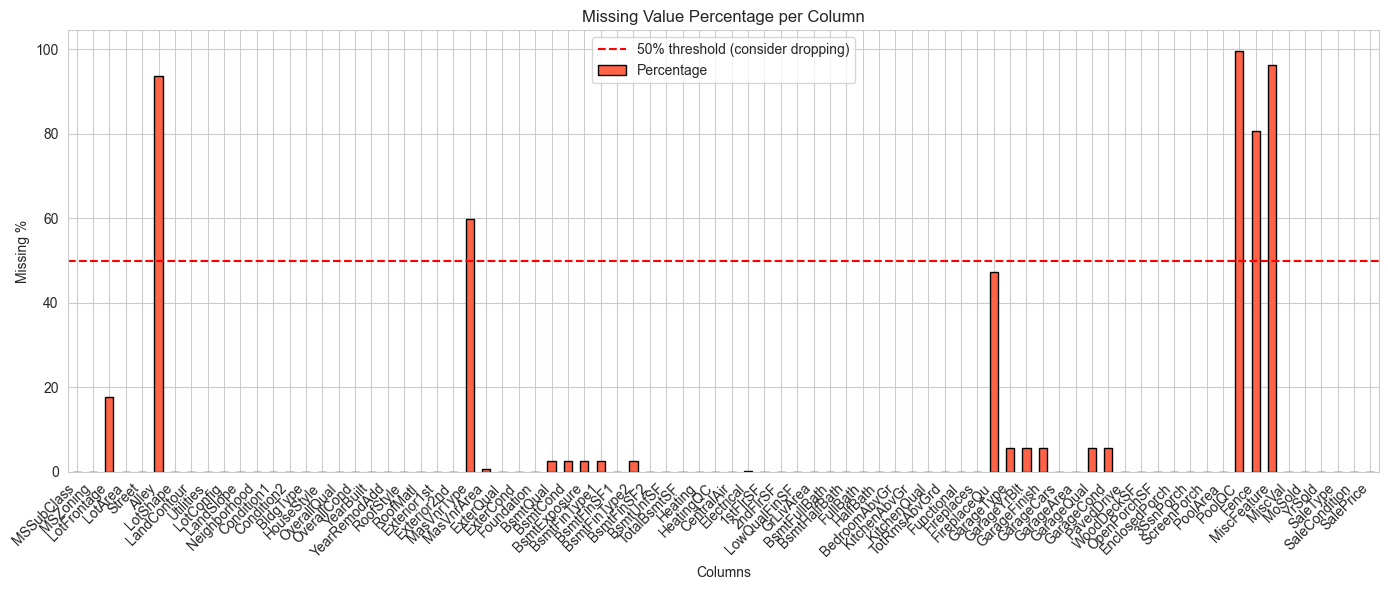

In [18]:
# Bar chart — which columns have how much % data missing
# WHY: So you can quickly decide visually — whether to drop or fill
# 50%+ missing = usually better to drop

plt.figure(figsize=(14, 6))
missing_df['Percentage'].plot(kind='bar', color='tomato', edgecolor='black')
plt.title("Missing Value Percentage per Column")
plt.ylabel("Missing %")
plt.xlabel("Columns")
plt.axhline(50, color='red', linestyle='--', label='50% threshold (consider dropping)')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("plots/10_missing_values.png", dpi=150)
plt.show()

In [19]:
# What percentage of values are missing in each column
# WHY: Missing data directly affects model training — cannot be ignored
# Skip columns with 0% missing, focus only on problematic columns

missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print("📋 Columns with Missing Values:")
print(missing_df)
print(f"\nTotal columns with missing data: {len(missing_df)}")

📋 Columns with Missing Values:
              Missing Count  Missing %
PoolQC                 1453  99.520548
MiscFeature            1406  96.301370
Alley                  1369  93.767123
Fence                  1179  80.753425
MasVnrType              872  59.726027
FireplaceQu             690  47.260274
LotFrontage             259  17.739726
GarageType               81   5.547945
GarageYrBlt              81   5.547945
GarageFinish             81   5.547945
GarageQual               81   5.547945
GarageCond               81   5.547945
BsmtExposure             38   2.602740
BsmtFinType2             38   2.602740
BsmtQual                 37   2.534247
BsmtCond                 37   2.534247
BsmtFinType1             37   2.534247
MasVnrArea                8   0.547945
Electrical                1   0.068493

Total columns with missing data: 19


In [20]:

# MISSING VALUE TREATMENT

cols_to_drop = missing_df[missing_df['Missing %'] > 80].index.tolist()
print(f"Dropping columns (>80% missing): {cols_to_drop}")
df.drop(columns=cols_to_drop, inplace=True)

# Categorical missing → "None" ---
# ================================

categorical_none_cols = [
    'Alley',        # No alley access
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',  # No basement
    'FireplaceQu',  # No fireplace
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',  # No garage
    'Fence',        # No fence
    'MiscFeature',  # No misc feature
    'MasVnrType'    # No masonry
]

# fill only those column which is present in dataframe
categorical_none_cols = [c for c in categorical_none_cols if c in df.columns]
for col in categorical_none_cols:
    df[col] = df[col].fillna("None")

# --- Step 3: Numeric missing → Median ---
# =========================================

numeric_cols_with_missing = df.select_dtypes(include=[np.number]).columns[
    df.select_dtypes(include=[np.number]).isnull().any()
].tolist()

for col in numeric_cols_with_missing:
    if col == 'GarageYrBlt':
        df[col] = df[col].fillna(0)  # 0 = no garage built
    else:
        df[col] = df[col].fillna(df[col].median())

# --- Step 4: Remaining categorical → Mode ---
# WHAT: The categorical columns that still had missing values were filled using the mode (most frequent)
# WHY: In categorical data, mode is the safest default choice
remaining_cat_missing = df.select_dtypes(include='object').columns[
    df.select_dtypes(include='object').isnull().any()
].tolist()

for col in remaining_cat_missing:
    df[col] = df[col].fillna(df[col].mode()[0])

# --- Verify: any missing value present or not ? ---
print(f"\n✅ Missing values after treatment: {df.isnull().sum().sum()}")
print(f"📐 Dataset shape after missing treatment: {df.shape}")

Dropping columns (>80% missing): ['PoolQC', 'MiscFeature', 'Alley', 'Fence']

✅ Missing values after treatment: 0
📐 Dataset shape after missing treatment: (1460, 76)


C:\Users\kumar\AppData\Local\Temp\ipykernel_16780\62378476.py:41: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  remaining_cat_missing = df.select_dtypes(include='object').columns[
C:\Users\kumar\AppData\Local\Temp\ipykernel_16780\62378476.py:42: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/

# ---------- STRATEGY ----------

  ### >80% missing → DROP the column entirely
    . Categorical → Fill with "None" (absence of feature means None)
    . Numeric → Fill with median (median is robust to outliers)

  ### Drop columns with >80% missing ---
    . WHAT: Removed columns with 80%+ missing data from the dataset

  ### WHY:

    . Filling such a large amount of missing data would be misleading — it would add noise

 ***Categorical missing → "None" ---***

    . In these features, NaN means the feature does not exist at all

 ### WHY:

    . e.g., PoolQC = NaN means no pool — "None" is the correct label, not unknown
    . These columns were identified using domain knowledge

## Step 3: Numeric missing → Median ---

    . Filled missing values in remaining numeric columns using the median

 ### WHY:

    . Median is not affected by outliers — a better choice than mean here
    . For GarageYrBlt, NaN means no garage, so fill with 0 instead of median

## Remaining categorical → Mode ---

    . Filled remaining categorical columns with missing values using the mode (most frequent)

### WHY:

    . For categorical data, mode is the safest default choice

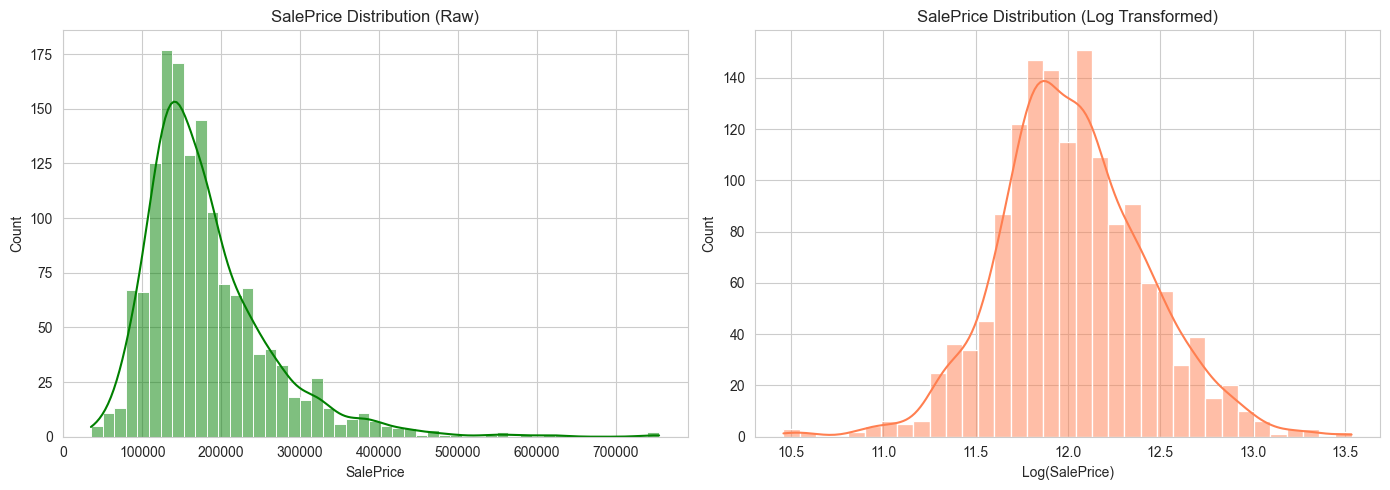

In [21]:
fig, axes = plt.subplots(1,2,  figsize=(14, 5))

sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='green')
axes[0].set_title("SalePrice Distribution (Raw)")
axes[0].set_xlabel("SalePrice")

# Right: Log-transformed SalePrice
# WHAT: Log(SalePrice) ka distribution
# WHY: if raw is skewed then it will become normal from log transformer → better model performance

sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=axes[1], color='coral')
axes[1].set_title("SalePrice Distribution (Log Transformed)")
axes[1].set_xlabel("Log(SalePrice)")

plt.tight_layout()
plt.savefig("plots/01_saleprice_distribution.png", dpi=150)
plt.show()



# 📊 Observations on SalePrice Distribution:
  ### 1. Raw SalePrice Distribution (Left Plot)

     . The distribution is positively skewed (right-skewed).
     . Most house prices are concentrated between 100k–200k, while a few properties have very high prices.
     . Presence of a long right tail indicates outliers and non-normality.
     . This violates the assumption of normal distribution required by many models like Linear Regression.

  ### 2. Log-Transformed SalePrice Distribution (Right Plot):

     . After applying log transformation, the distribution becomes approximately symmetric and bell-shaped.
     . Skewness is significantly reduced.
     . Outliers are compressed, making the data more stable.

  ### 3. Conclusion:

     . Since the original target variable is skewed, applying log transformation is necessary.
     . The transformed target is closer to normal distribution, which improves model performance and reliability.
     . Therefore, we will use log(SalePrice) as the target variable for modeling.

C:\Users\kumar\AppData\Local\Temp\ipykernel_16780\3816579049.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='OverallQual', y='SalePrice', data=df, palette='RdYlGn')


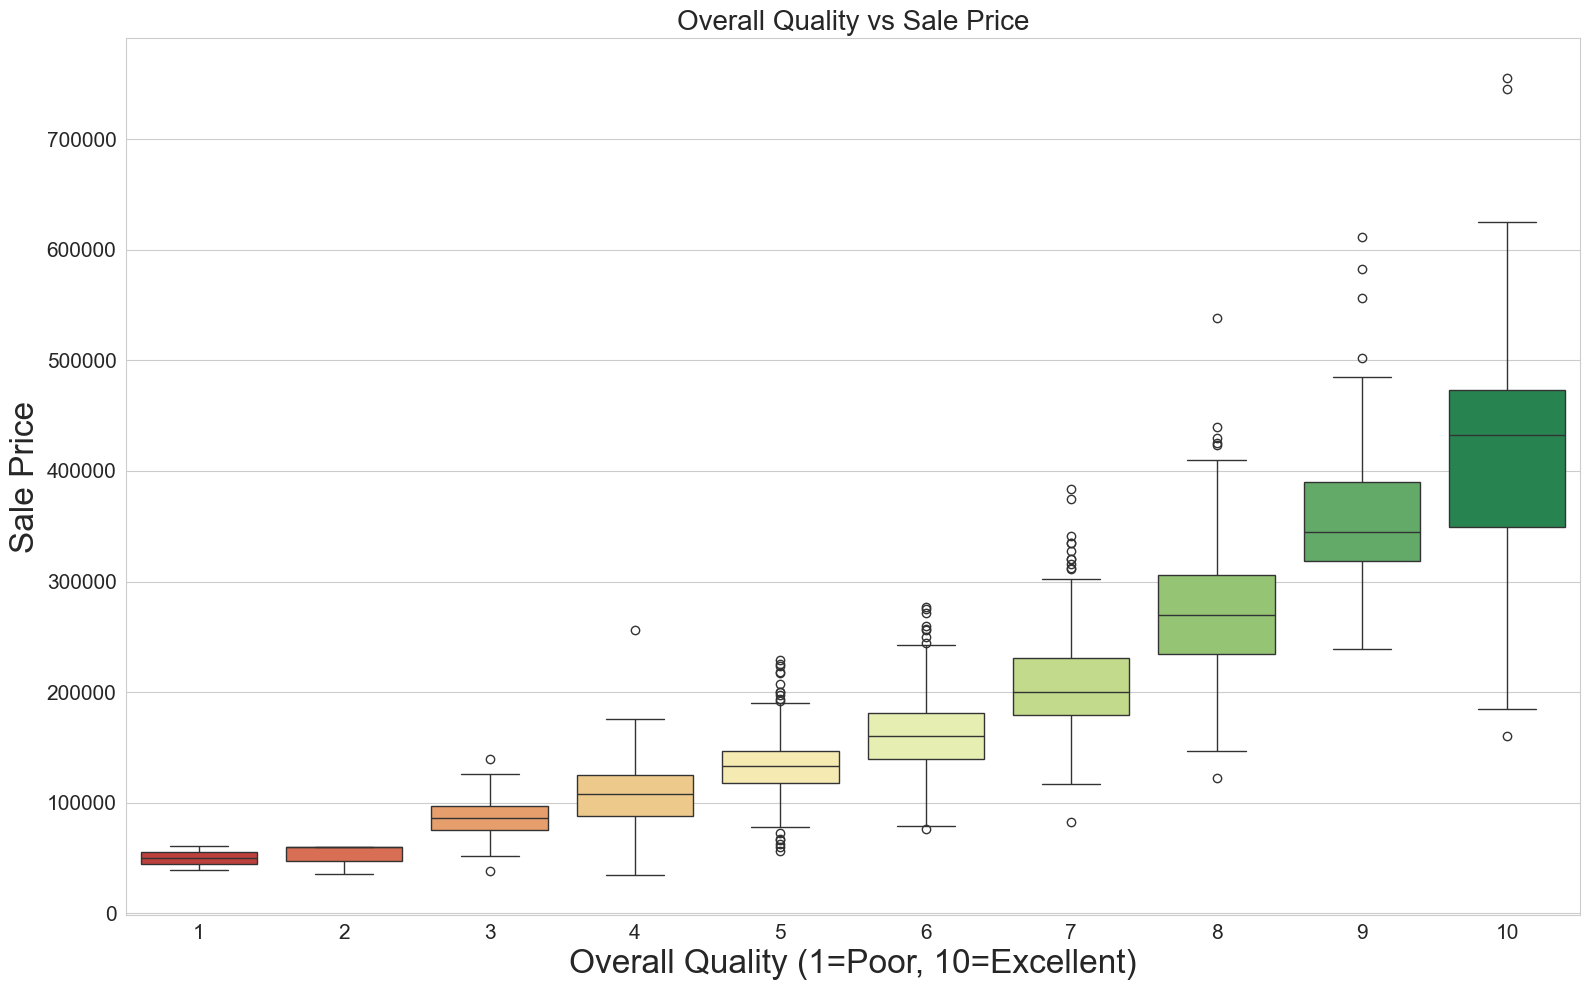

In [22]:
plt.figure(figsize=(16, 10))  # width, height increase kiya
sns.boxplot(x='OverallQual', y='SalePrice', data=df, palette='RdYlGn')

plt.title("Overall Quality vs Sale Price", fontsize=20)
plt.xlabel("Overall Quality (1=Poor, 10=Excellent)", fontsize=24)
plt.ylabel("Sale Price", fontsize=24)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.tight_layout()
plt.savefig("plots/02_quality_vs_price.png", dpi=300)
plt.show()

# 📊 Observations: Overall Quality vs Sale Price
### 1. Strong Positive Relationship:

    . As Overall Quality increases (1 → 10), the median SalePrice increases significantly.
    . This confirms that OverallQual is a highly important feature for predicting house prices.

### 2. Clear Price Segmentation:

    . Lower quality houses (1–4) have consistently lower price ranges.
    . Higher quality houses (8–10) show much higher price ranges, especially 9 and 10, where prices are significantly higher.

### 3. Increasing Variability at Higher Quality:

    . Spread (IQR) increases for higher quality levels.
    . This means premium houses have more price variation, possibly due to additional luxury features (location, area, amenities).

### 4. Presence of Outliers:

    . Several outliers are visible across multiple quality levels.
    . Some houses have unusually high or low prices compared to their quality.
    . These should be investigated further (possible data issues or special cases).

### 5. Conclusion:

    . OverallQual is one of the strongest predictors of SalePrice.
    . It should definitely be included in the model.
    . Outliers may need treatment or validation before modeling.

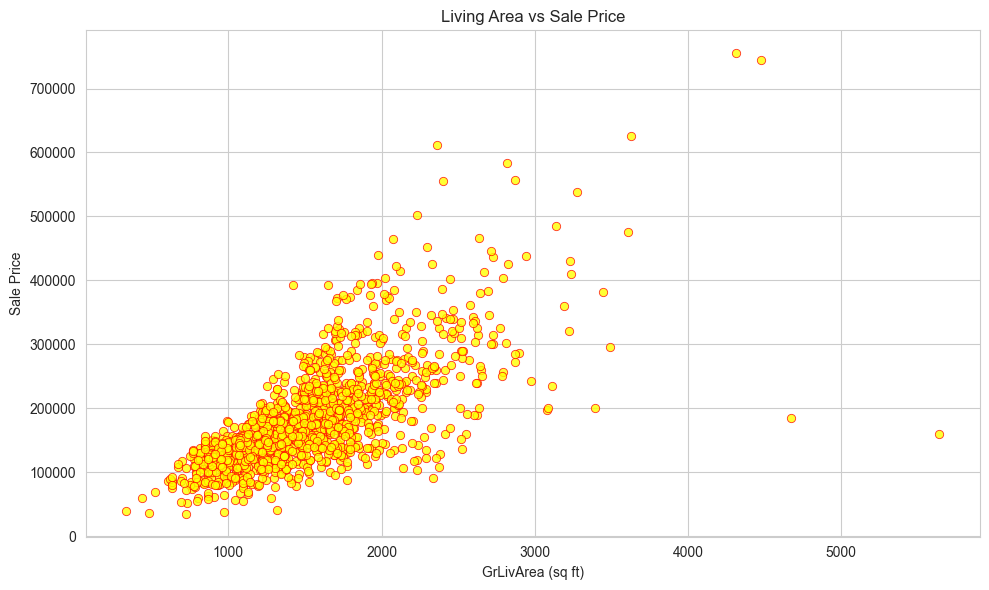

In [23]:
# Scatter plot of ground living area (sqft) vs price
# WHY: To check the linear relationship between area and price — to understand the impact of a continuous feature

plt.figure(figsize=(10, 6))
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.8, color='yellow', edgecolors='r', linewidths=0.6)
plt.title("Living Area vs Sale Price")
plt.xlabel("GrLivArea (sq ft)")
plt.ylabel("Sale Price")
plt.tight_layout()
plt.savefig("plots/03_area_vs_price.png", dpi=1000)
plt.show()

# 📊 Observations: Area vs Sale Price
### 1. Positive Relationship:

    . There is a clear positive correlation between area (e.g., GrLivArea) and SalePrice.
    . As the area increases, the sale price also increases.
    . This indicates that area is a strong predictor of house price.

### 2. Linear Trend:

    . Most data points follow a linear upward trend, which is good for models like Linear Regression.

### 3. Presence of Outliers:

    . A few points are visible in the bottom-right corner (very high area but relatively low price).
    . These are anomalies and do not follow the general trend.

### 4. Conclusion:

    . Area is an important feature and should be included in the model.
    . The identified outliers should be investigated and possibly removed to improve model performance.

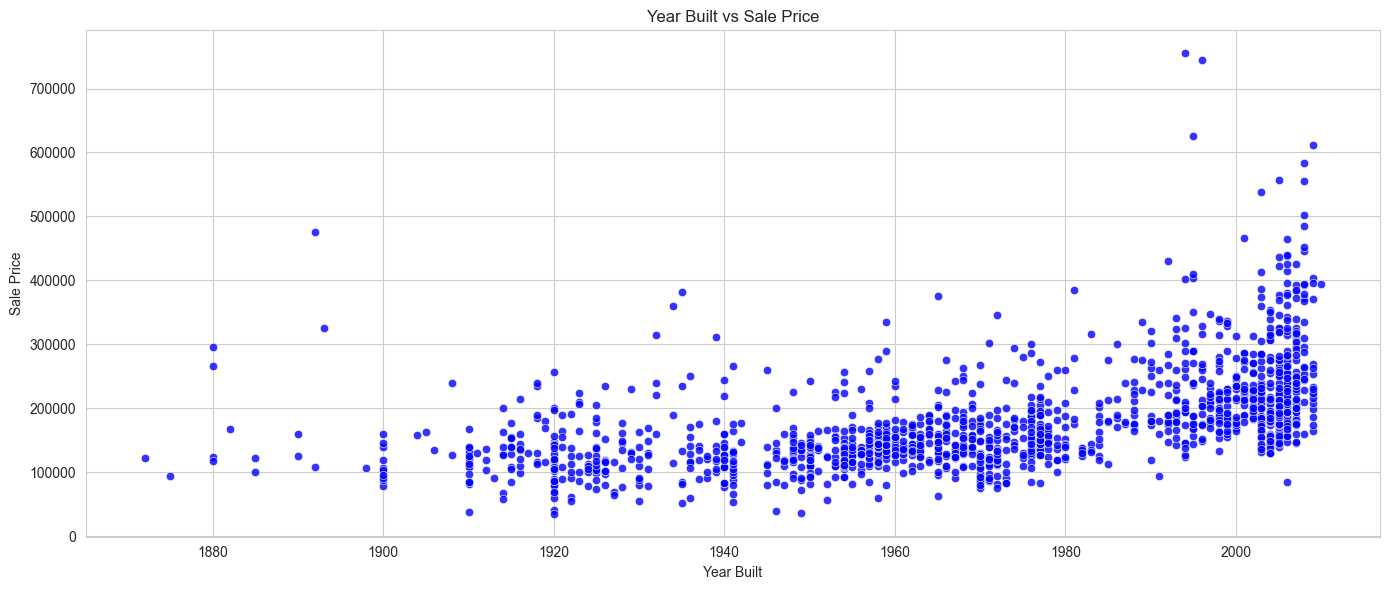

In [24]:
# Relationship between house construction year and sale price
# WHY: Newer houses tend to be more expensive — to observe price trends over time
# EDGE: Older houses (pre-1950) will have higher variance — due to historic/renovated properties

plt.figure(figsize=(14, 6))
sns.scatterplot(x='YearBuilt', y='SalePrice', data=df, alpha=0.8, color='blue')
plt.title("Year Built vs Sale Price")
plt.xlabel("Year Built")
plt.ylabel("Sale Price")
plt.tight_layout()
plt.savefig("plots/04_yearbuilt_vs_price.png", dpi=1000)
plt.show()

# 📊 Observations: Year Built vs Sale Price
## 1. Positive Trend (Newer Houses = Higher Price):

    . Newer houses (recent years) generally have higher sale prices.
    . This shows that YearBuilt has a positive impact on price.

 ## 2. Weak to Moderate Relationship:

     . The trend is upward, but not very strong or perfectly linear.
     . There is significant variation in prices even among houses built in the same year.
     . This indicates that other factors (area, quality, location) also play a big role.

## 3. Higher Variability in Recent Years:

     . Newer houses (after ~2000) show higher price spread.
     . This suggests the presence of both mid-range and luxury properties.

## 4. Older Houses:

    . Older houses (before 1950) generally have lower prices, but there are some exceptions.
    . These exceptions could be due to renovation, location, or premium features.

## 5. Outliers Present:

    . Some points show unusually high or low prices for certain years.
    . These should be investigated further.

## 6. Conclusion:

    . YearBuilt is an important feature, but not as strong as OverallQual or Area.
    . It can be improved by feature engineering such as:
    . HouseAge = CurrentYear - YearBuilt

C:\Users\kumar\AppData\Local\Temp\ipykernel_16780\1771793688.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Neighborhood', y='SalePrice', data=df, order=order, palette='viridis')


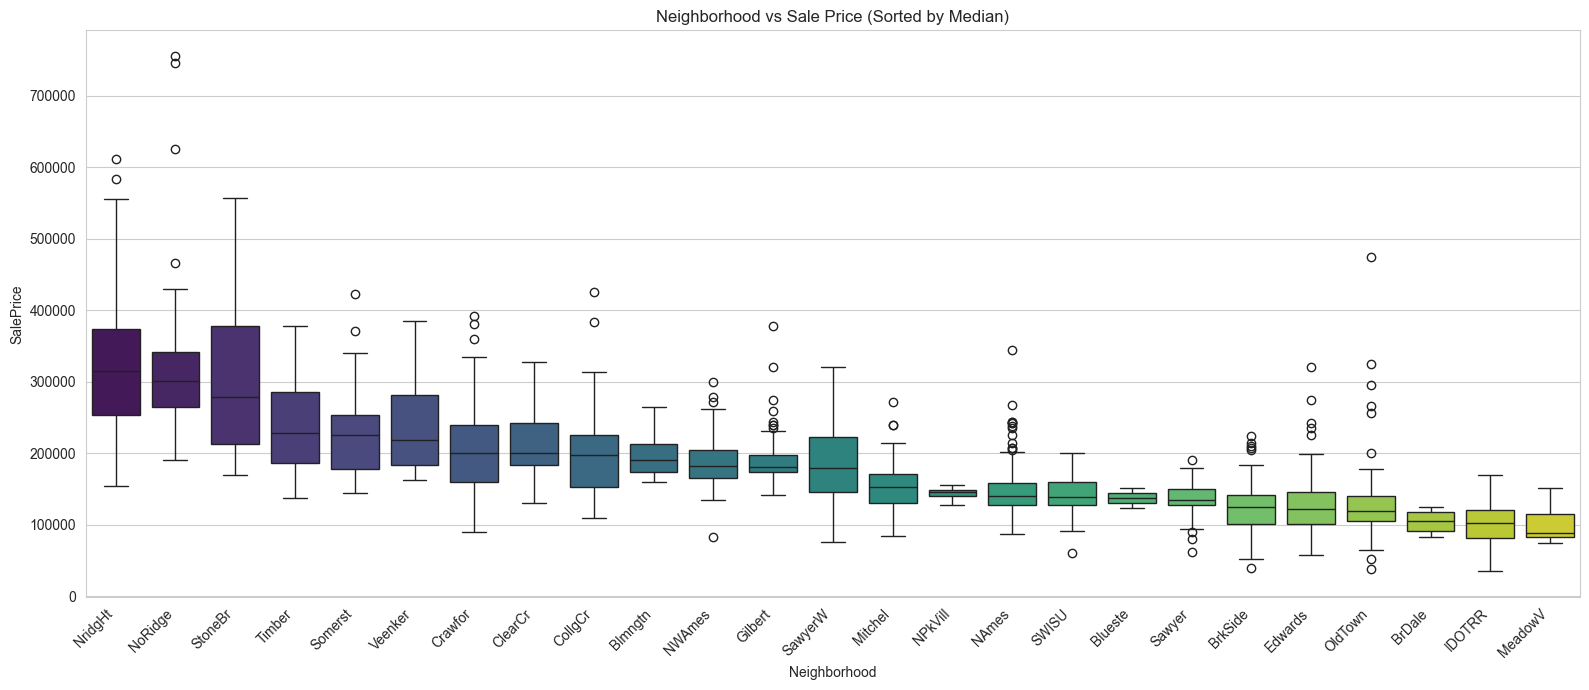

In [25]:
plt.figure(figsize=(16, 7))
order = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index
sns.boxplot(x='Neighborhood', y='SalePrice', data=df, order=order, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title("Neighborhood vs Sale Price (Sorted by Median)")
plt.tight_layout()
plt.savefig("plots/05_neighborhood_vs_price.png", dpi=1000)
plt.show()

# 🔍 Key Observations
## 1. High-price neighborhoods (top side)

    . Neighborhoods like NridgHt, NoRidge, and StoneBr have the highest median sale prices.

### In these areas:

    . Houses are expensive.
    . Upper whiskers and outliers are also in the high range → indicating luxury properties.

## 2. Low-price neighborhoods (bottom side)

    . Areas like MeadowV, IDOTRR, and BrDale have the lowest median prices.

### These are generally:

    . Affordable housing areas.
    . Price range is also relatively narrow (less variation).

## 3. Price variation
    In some neighborhoods (such as NridgHt, StoneBr):

    . The box (IQR) is large → high variability in prices.

### In some areas (such as Blueste, SWISU):

    . The box is small → prices are relatively consistent.

## 4. Outliers (extreme values)

    . Outliers are present in many neighborhoods.

### This indicates:

    . Some properties are unusually expensive or cheap.

### Example:

    . Very high-price outliers in premium areas (luxury homes).
    . Occasionally unexpected high values in low-end areas.

## 5. Median trend (left → right)

    . The graph is clearly sorted in descending order based on median values.

### * Moving from left to right: *

    . Sale prices gradually decrease.
    . This shows overall market segmentation.

## 6. Overlap between neighborhoods

    . Price ranges of some neighborhoods overlap.

### Example:

    . Mid-tier areas like CollgCr, Crawfor, and Veenker.

### This means:

    . Similarly priced houses can be found in different locations.

# 📝 Conclusion (Short Summary for Notebook)

    . SalePrice strongly depends on Neighborhood.
    . High-end neighborhoods have high median prices and large spread.
    . Low-end neighborhoods have low median prices and less variation.
    . Outliers indicate special or luxury properties.
    . Overall trend: clear price gradient across neighborhoods.

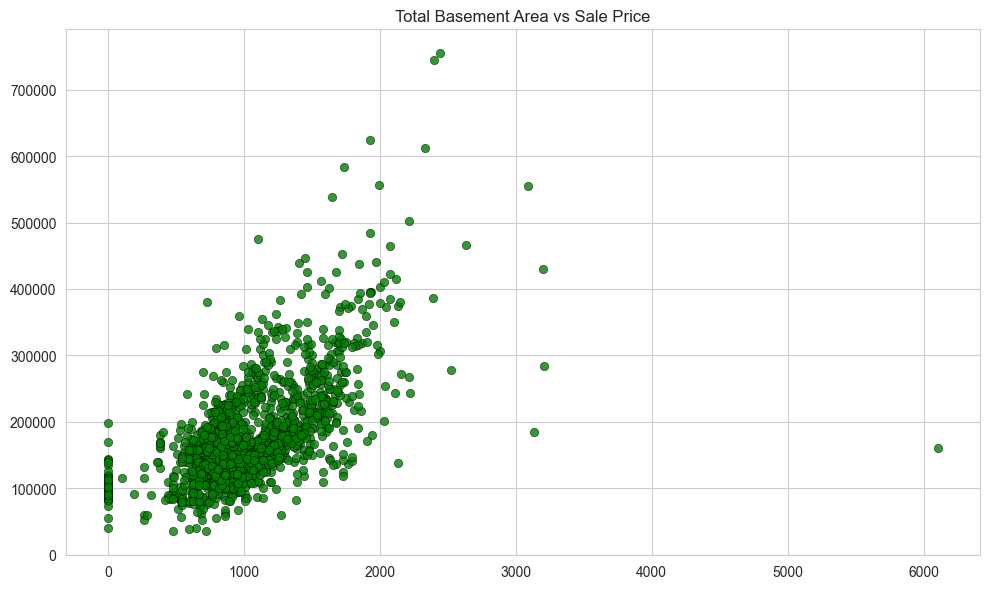

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(df['TotalBsmtSF'], df['SalePrice'], alpha=0.8, color='green', edgecolors='k', linewidths=0.4)
plt.title("Total Basement Area vs Sale Price")
plt.tight_layout()
plt.savefig("plots/07_basement_vs_price.png", dpi=1000)
plt.show()

# 🔹 Part 1: Relationship & Distribution

    . The scatter plot clearly shows a positive relationship between Total Basement Area and Sale Price.
    . (As basement area increases, the price also increases.)

### Maximum data points:

     . Basement area lies between 500–2000 sq ft.
     . Sale prices are clustered in the range of 100k–300k.

### This indicates that:

     . Most houses belong to the mid-size and mid-price category.

# 🔹 Part 2: Variability & Outliers
### As basement area increases:

### Price variation also increases
(Same basement area has different prices.)

    . Some outliers are also present:
    . Very large basement but low price.
    . Moderate basement but very high price.

    . Some houses also have zero basement area:
    . Their prices are generally on the lower side.

### This shows that:

    . Basement area is important, but price does not depend only on this factor.

# 📝 Conclusion:

    . A positive correlation exists between Total Basement Area and Sale Price.
    . However, the relationship is not perfectly linear.
    . Other factors (location, quality, etc.) are also important in influencing price.
    . Outliers and variability indicate that real estate pricing is complex.

# Target + Train-Test Split
## TARGET VARIABLE + TRAIN TEST SPLIT

    . WHAT: Separate features (X) and target (y), then split the data.
    . WHY: The model needs to learn on training data and be evaluated on test data.
    . EDGE: Apply log transformation on SalePrice — the distribution was skewed. The model will predict log-price, later apply inverse transform to get the actual price.

In [27]:
from sklearn.model_selection import train_test_split


X = df.drop(['SalePrice'], axis=1)
y = np.log1p(df['SalePrice'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Split complete!")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y range : {y_train.min():.2f} to {y_train.max():.2f}  ← log scale sahi hai")


✅ Split complete!
X_train : (1168, 75)
X_test  : (292, 75)
y range : 10.46 to 13.52  ← log scale sahi hai


# CORRELATION ANALYSIS

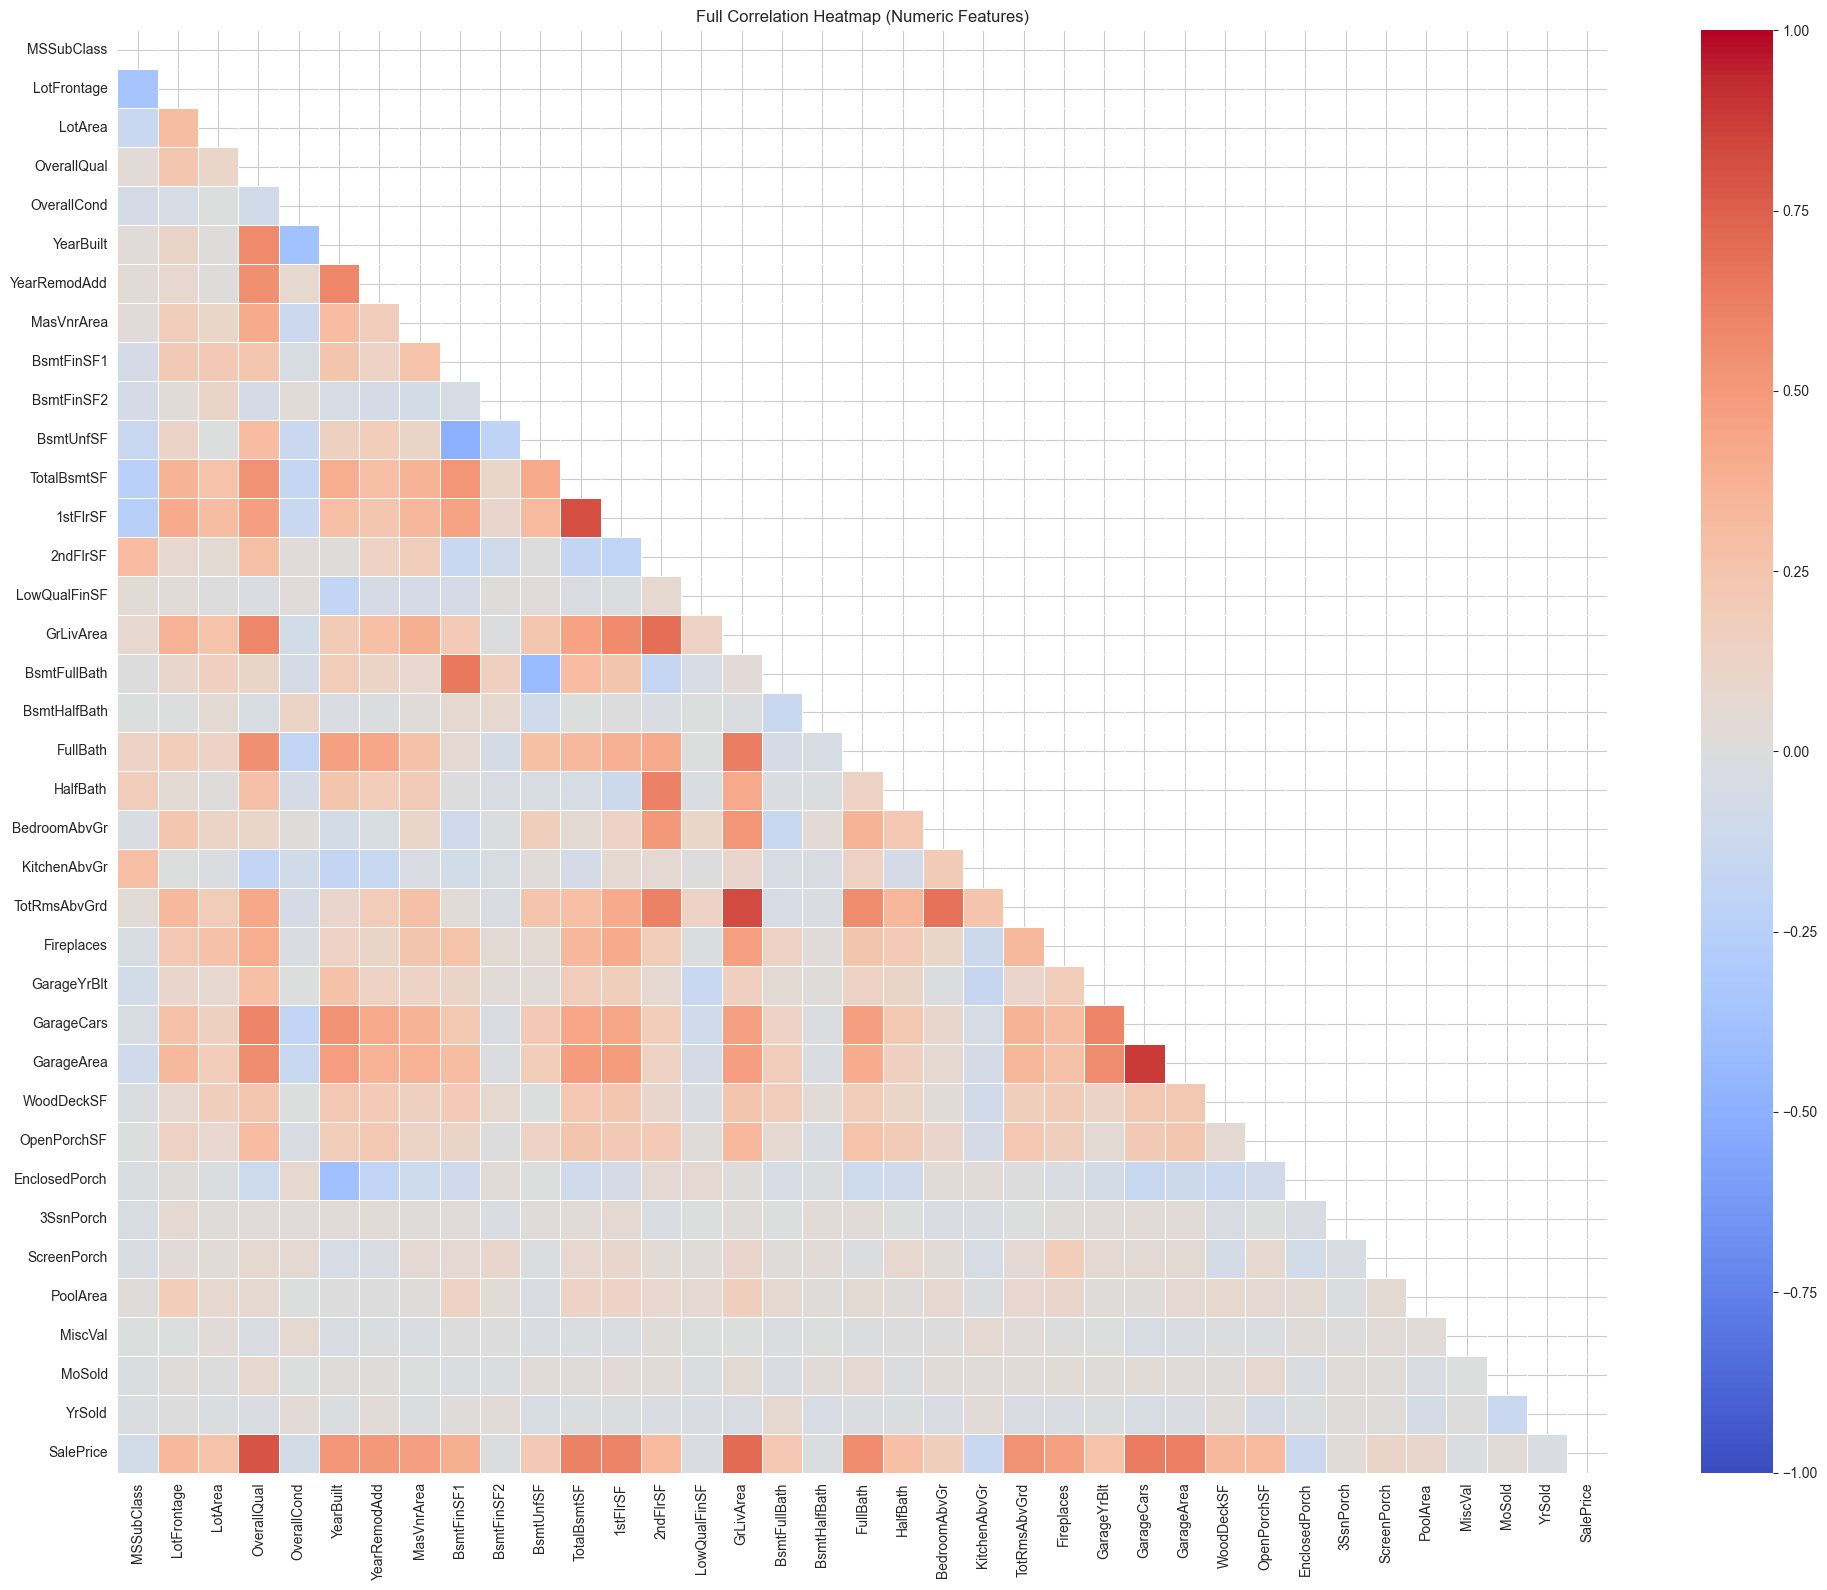


📊 TOP 15 Positively Correlated Features:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.334771
WoodDeckSF      0.324413
Name: SalePrice, dtype: float64

📊 TOP 10 Negatively Correlated Features:
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


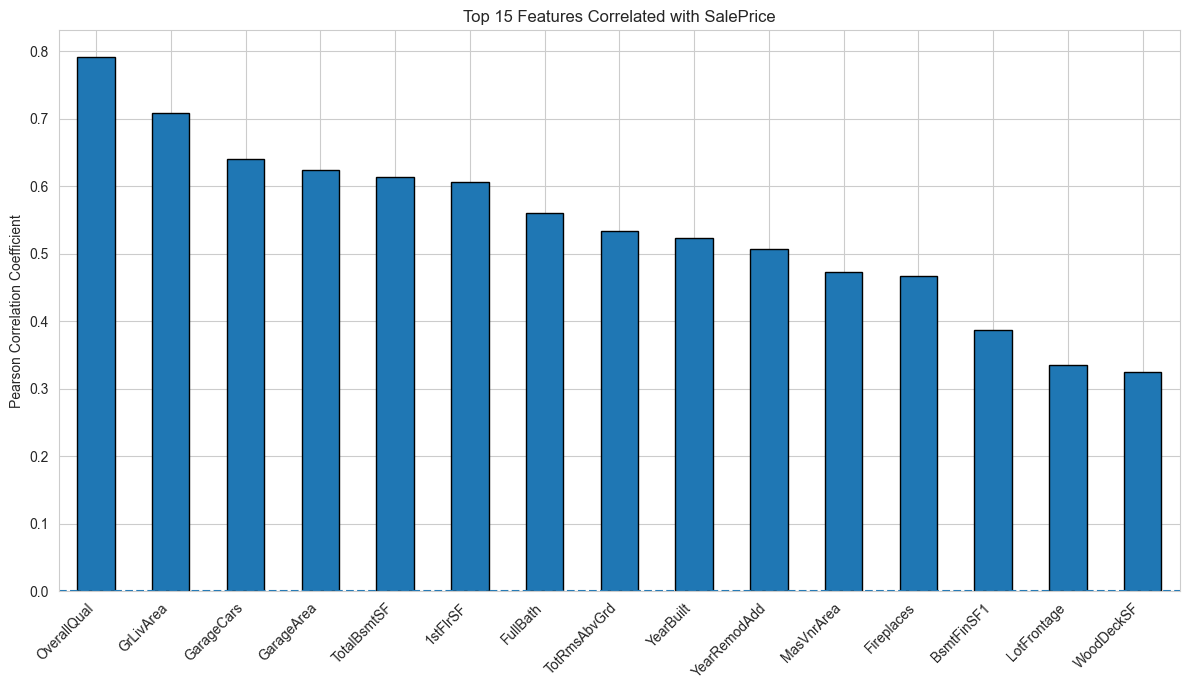


⚠️ Highly Correlated Feature Pairs (>0.85):
GarageCars  ↔  GarageArea  →  r = 0.882


In [28]:
# ==============================
# CORRELATION ANALYSIS (FIXED)
# ==============================

numeric_df = df.select_dtypes(include=[np.number])

# 🔹 Step 3: Correlation Matrix
plt.figure(figsize=(20, 16))
corr_matrix = numeric_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    vmin=-1, vmax=1
)

plt.title("Full Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.savefig("plots/08_full_correlation_heatmap.png", dpi=1000)
plt.show()

# ==============================
# 🔹 Top Correlated Features
# ==============================

salePrice_corr = corr_matrix['SalePrice'].drop('SalePrice').sort_values(ascending=False)

print("\n📊 TOP 15 Positively Correlated Features:")
print(salePrice_corr.head(15))

print("\n📊 TOP 10 Negatively Correlated Features:")
print(salePrice_corr.tail(10))

# ==============================
# 🔹 Bar Plot
# ==============================

plt.figure(figsize=(12, 7))
salePrice_corr.head(15).plot(kind='bar', edgecolor='black')
plt.title("Top 15 Features Correlated with SalePrice")
plt.ylabel("Pearson Correlation Coefficient")
plt.xticks(rotation=45, ha='right')
plt.axhline(0, linestyle='--')
plt.tight_layout()
plt.savefig("plots/09_top_correlated_features.png", dpi=300)
plt.show()

# ==============================
# 🔹 Multicollinearity Check
# ==============================

print("\n⚠️ Highly Correlated Feature Pairs (>0.85):")

high_corr_pairs = []
cols = corr_matrix.columns.tolist()

# remove target
cols.remove('SalePrice')

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        val = corr_matrix.loc[cols[i], cols[j]]
        if abs(val) > 0.85:
            high_corr_pairs.append((cols[i], cols[j], round(val, 3)))

for pair in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"{pair[0]}  ↔  {pair[1]}  →  r = {pair[2]}")

# 🔹 Part 1: Strong Positive Features

### These features show a strong positive correlation with SalePrice, meaning they directly influence the price:

    . OverallQual (0.79) → Most important (house quality)
    . GrLivArea (0.70) → The larger the living area, the higher the price
    . GarageCars (0.64), GarageArea (0.62) → Garage size is important
    . TotalBsmtSF (0.61), 1stFlrSF (0.60) → Area-related features are strong
    . FullBath, TotRmsAbvGrd → More rooms/bathrooms → higher price
    . YearBuilt, YearRemodAdd → New or renovated houses are more expensive

## 👉 Conclusion (of this part):

    . Size, quality, and construction-related features are the most important predictors.
    . These should definitely be kept.

# 🔹 Part 2: Weak / Negative Features

    . These features either:

    . Show very low correlation.
    . Or show negative correlation (do not affect price much or have an inverse effect).

# Important weak features:

    . KitchenAbvGr (-0.13)
    . EnclosedPorch (-0.12)
    . MSSubClass, OverallCond → weak impact
    . MiscVal, BsmtHalfBath, BsmtFinSF2 → almost no impact

## 👉 Conclusion:

    . Their contribution is very low.
    . In feature selection:
    . They can be removed.
    . Or given low priority.

# 🔹 Part 3: Moderate Features

    . These features show moderate correlation:

    . MasVnrArea, Fireplaces
    . BsmtFinSF1, LotFrontage

## 👉 These:

    . Can be useful.
    . But are not as strong as the top features.

## 👉 Therefore:

    . They can be kept in an advanced model.
    . They are optional in a simple model.

# 📝 Final Conclusion

    . SalePrice depends the most on:
    . Overall quality, living area, garage size, and total area.

    . Weak and negative features have very little impact, so they can be removed.

    . The dataset clearly shows that:

## Size + Quality = High Price

     . For feature selection:
     . Strong features → keep
     . Weak features → remove
     . Moderate features → optional

In [29]:
# =============================================
# OUTLIER REMOVAL
# =============================================

print(f"Shape before outlier removal: {df.shape}")

df = df[~((df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000))]
print(f"After GrLivArea outlier removal: {df.shape}")


iqr_cols = ['LotArea', 'TotalBsmtSF', '1stFlrSF', 'GarageArea', 'MasVnrArea']

for col in iqr_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    before = df.shape[0]
    df = df[(df[col] >= lower) & (df[col] <= upper)]
    after = df.shape[0]
    print(f"  {col}: removed {before - after} rows")

print(f"\n✅ Final shape after all outlier removal: {df.shape}")

Shape before outlier removal: (1460, 76)
After GrLivArea outlier removal: (1458, 76)
  LotArea: removed 66 rows
  TotalBsmtSF: removed 63 rows
  1stFlrSF: removed 5 rows
  GarageArea: removed 9 rows
  MasVnrArea: removed 74 rows

✅ Final shape after all outlier removal: (1241, 76)


# 📊 Before/After Outlier Plot

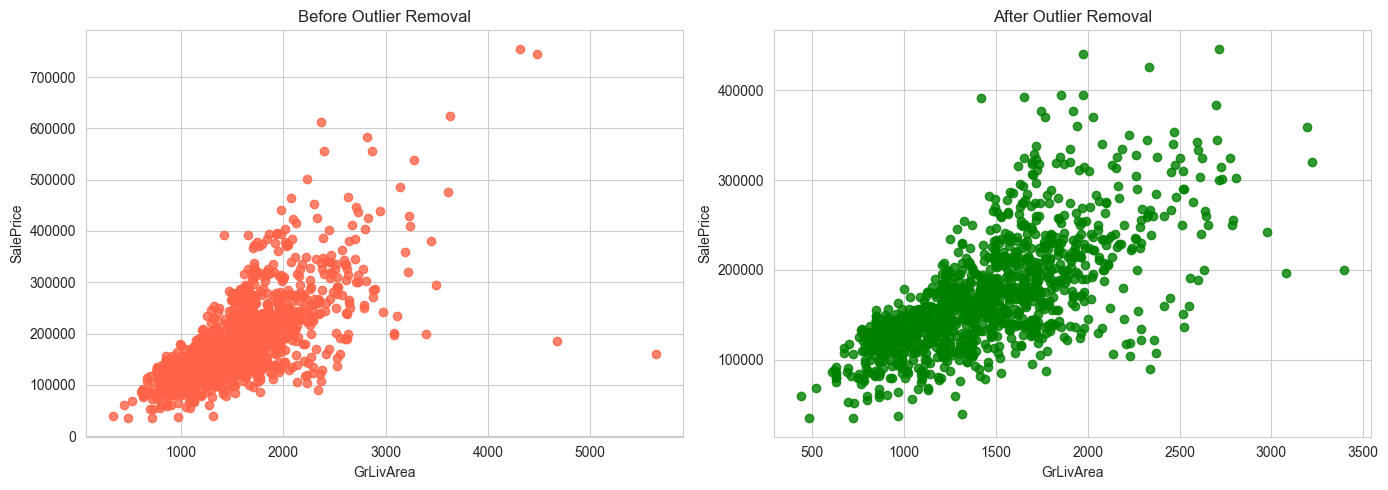

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before (original data reload karke dikhao)
df_orig = pd.read_csv(r'C:\Users\kumar\OneDrive\Documents\house-price-predicition\data\train Data House Price.csv')
axes[0].scatter(df_orig['GrLivArea'], df_orig['SalePrice'], alpha=0.8, color='tomato')
axes[0].set_title("Before Outlier Removal")
axes[0].set_xlabel("GrLivArea")
axes[0].set_ylabel("SalePrice")

# After
axes[1].scatter(df['GrLivArea'], df['SalePrice'], alpha=0.8, color='green')
axes[1].set_title("After Outlier Removal")
axes[1].set_xlabel("GrLivArea")
axes[1].set_ylabel("SalePrice")

plt.tight_layout()
plt.savefig("plots/11_outlier_removal_comparison.png", dpi=1000)
plt.show()

## 🔹1. Before vs After Outlier Removal
### Before outlier removal:

    . Many extreme values (outliers) were present in the data.
    . The scatter plot was messy and the relationship was not clear.

### After outlier removal:

    . The data became cleaner and more structured.
    . The relationship between GrLivArea and SalePrice became clearly positive and linear.

### 👉 This shows that outliers were distorting the model.

## 🔹2. Impact on Dataset & Data Quality
### Dataset size:

     . Before: (1460, 76)
     . After: (1241, 76)

     . Many rows were removed (LotArea, TotalBsmtSF, MasVnrArea, etc.).

### After outlier removal:

    . Noise was reduced.
    . The data became more reliable and consistent.
    . Better quality data was available for model training.

# 📝 Conclusion

    . Outlier removal is an important preprocessing step.
    . It reduces the size of the data, but improves its quality.
    . Relationships become more clearly visible in clean data.
    . In this case, the relationship between GrLivArea and SalePrice became strong and clear, which will improve model performance.

# 📝 Statistical Test

### 1. Pearson Test (Numeric Features)

    . WHAT: Linear correlation test of numeric features with SalePrice.
    . WHY: To check whether a numeric feature has a real relationship with price or not.
    . EDGE: Use log-transformed SalePrice — Pearson assumes a normal distribution.

In [31]:
# WHAT: Linear correlation test of numeric features with SalePrice
# WHY: To check whether a numeric feature has a real relationship with price or not
# EDGE: Use log-transformed SalePrice — Pearson assumes a normal distribution

log_price = np.log1p(df['SalePrice'])

numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [f for f in numeric_features if f not in ['SalePrice', 'Id']]

pearson_results = []

for col in numeric_features:
    corr, p_val = stats.pearsonr(df[col], log_price)
    pearson_results.append({
        'Feature'    : col,
        'Correlation': round(corr, 4),
        'p-value'    : round(p_val, 6),
        'Significant': '✅ YES' if p_val < 0.05 else '❌ NO'
    })

pearson_df = pd.DataFrame(pearson_results).sort_values('p-value')

print("=" * 55)
print("📊 PEARSON TEST RESULTS — Numeric Features")
print("=" * 55)
print(pearson_df.to_string(index=False))

not_sig_pearson = pearson_df[pearson_df['Significant'] == '❌ NO']
print(f"\n✅ Significant   : {len(pearson_df[pearson_df['Significant'] == '✅ YES'])}")
print(f"❌ Non-Significant: {len(not_sig_pearson)}")
print("\n⚠️ Weak Numeric Features:")
print(not_sig_pearson[['Feature', 'p-value']].to_string(index=False))

📊 PEARSON TEST RESULTS — Numeric Features
      Feature  Correlation  p-value Significant
  LotFrontage       0.3297 0.000000       ✅ YES
      LotArea       0.3917 0.000000       ✅ YES
  OverallQual       0.7967 0.000000       ✅ YES
    YearBuilt       0.6081 0.000000       ✅ YES
   MasVnrArea       0.3612 0.000000       ✅ YES
 YearRemodAdd       0.5766 0.000000       ✅ YES
    BsmtUnfSF       0.1572 0.000000       ✅ YES
   BsmtFinSF1       0.3144 0.000000       ✅ YES
    GrLivArea       0.6751 0.000000       ✅ YES
     2ndFlrSF       0.2994 0.000000       ✅ YES
  TotalBsmtSF       0.5790 0.000000       ✅ YES
     1stFlrSF       0.5714 0.000000       ✅ YES
 BedroomAbvGr       0.2161 0.000000       ✅ YES
     HalfBath       0.2888 0.000000       ✅ YES
     FullBath       0.6074 0.000000       ✅ YES
 BsmtFullBath       0.1883 0.000000       ✅ YES
  OpenPorchSF       0.3118 0.000000       ✅ YES
EnclosedPorch      -0.1849 0.000000       ✅ YES
   GarageArea       0.6362 0.000000       ✅ YE

### 2. Spearman Test (Numeric Features)

     . WHAT: Alternative to Pearson — it can also capture non-linear relationships.
     . WHY: Some numeric features are skewed, where Pearson may fail. Spearman is rank-based, so it works well on skewed data.
     . EDGE: If a feature is weak in both Pearson and Spearman, it should definitely be dropped.

In [32]:
spearman_results = []

for col in numeric_features:
    corr, p_val = stats.spearmanr(df[col], df['SalePrice'])
    spearman_results.append({
        'Feature'    : col,
        'Correlation': round(corr, 4),
        'p-value'    : round(p_val, 6),
        'Significant': '✅ YES' if p_val < 0.05 else '❌ NO'
    })

spearman_df = pd.DataFrame(spearman_results).sort_values('p-value')

print("=" * 55)
print("📊 SPEARMAN TEST RESULTS — Numeric Features")
print("=" * 55)
print(spearman_df.to_string(index=False))

not_sig_spearman = spearman_df[spearman_df['Significant'] == '❌ NO']
print(f"\n✅ Significant   : {len(spearman_df[spearman_df['Significant'] == '✅ YES'])}")
print(f"❌ Non-Significant: {len(not_sig_spearman)}")
print("\n⚠️ Weak Numeric Features (Spearman):")
print(not_sig_spearman[['Feature', 'p-value']].to_string(index=False))

📊 SPEARMAN TEST RESULTS — Numeric Features
      Feature  Correlation  p-value Significant
  LotFrontage       0.3542 0.000000       ✅ YES
      LotArea       0.4069 0.000000       ✅ YES
  OverallQual       0.7951 0.000000       ✅ YES
  OverallCond      -0.1540 0.000000       ✅ YES
 YearRemodAdd       0.5829 0.000000       ✅ YES
    YearBuilt       0.6667 0.000000       ✅ YES
   MasVnrArea       0.3671 0.000000       ✅ YES
   BsmtFinSF1       0.2378 0.000000       ✅ YES
    GrLivArea       0.7019 0.000000       ✅ YES
  TotalBsmtSF       0.5331 0.000000       ✅ YES
     2ndFlrSF       0.2892 0.000000       ✅ YES
     1stFlrSF       0.5383 0.000000       ✅ YES
 BedroomAbvGr       0.2347 0.000000       ✅ YES
     HalfBath       0.3269 0.000000       ✅ YES
     FullBath       0.6547 0.000000       ✅ YES
 BsmtFullBath       0.1716 0.000000       ✅ YES
  OpenPorchSF       0.4701 0.000000       ✅ YES
EnclosedPorch      -0.2478 0.000000       ✅ YES
   GarageArea       0.6273 0.000000       ✅ Y

### 3. ANOVA Test (Categorical Features)

     . WHAT: Compares the mean SalePrice of each category in a categorical feature.
     . WHY: To check whether changing the category significantly changes the price or not.
     . Example: Does changing the Neighborhood change the price?
     . EDGE: p < 0.05 means at least one category has a significantly different mean.

In [33]:
categorical_features = df.select_dtypes(include='object').columns.tolist()

anova_results = []

for col in categorical_features:
    groups = [
        df[df[col] == cat]['SalePrice'].values
        for cat in df[col].unique()
        if len(df[df[col] == cat]) > 1
    ]

    if len(groups) >= 2:
        f_stat, p_val = stats.f_oneway(*groups)
        anova_results.append({
            'Feature'    : col,
            'F-Statistic': round(f_stat, 4),
            'p-value'    : round(p_val, 6),
            'Significant': '✅ YES' if p_val < 0.05 else '❌ NO'
        })

anova_df = pd.DataFrame(anova_results).sort_values('p-value')

print("=" * 55)
print("📊 ANOVA TEST RESULTS — Categorical Features")
print("=" * 55)
print(anova_df.to_string(index=False))

not_sig_anova = anova_df[anova_df['Significant'] == '❌ NO']
print(f"\n✅ Significant   : {len(anova_df[anova_df['Significant'] == '✅ YES'])}")
print(f"❌ Non-Significant: {len(not_sig_anova)}")
print("\n⚠️ Weak Categorical Features:")
print(not_sig_anova[['Feature', 'p-value']].to_string(index=False))

C:\Users\kumar\AppData\Local\Temp\ipykernel_16780\1005977342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include='object').columns.tolist()


📊 ANOVA TEST RESULTS — Categorical Features
      Feature  F-Statistic  p-value Significant
     MSZoning      54.8969 0.000000       ✅ YES
     LotShape      27.6382 0.000000       ✅ YES
  LandContour      12.5169 0.000000       ✅ YES
   Condition1       6.9425 0.000000       ✅ YES
 Neighborhood      61.4284 0.000000       ✅ YES
  Exterior2nd      19.8684 0.000000       ✅ YES
   HouseStyle      21.6868 0.000000       ✅ YES
     BldgType       9.2429 0.000000       ✅ YES
   MasVnrType     102.1464 0.000000       ✅ YES
  Exterior1st      31.9303 0.000000       ✅ YES
 BsmtExposure      38.9910 0.000000       ✅ YES
     BsmtCond      15.3283 0.000000       ✅ YES
     BsmtQual     340.6082 0.000000       ✅ YES
   Foundation     129.2525 0.000000       ✅ YES
    ExterCond      12.8456 0.000000       ✅ YES
    ExterQual     346.6981 0.000000       ✅ YES
   GarageType      79.5148 0.000000       ✅ YES
   CentralAir      94.7905 0.000000       ✅ YES
   Electrical      27.9415 0.000000       ✅ 

## 🗑️ 4 Weak Features Drop

    . WHAT: Drop statistically non-significant categorical features.
    . WHY: The ANOVA test confirmed that these features do not have any meaningful impact on SalePrice — they will add noise to the model.
    . EDGE: Street, LandSlope, MiscFeature, PoolQC — p > 0.05 means their categories do not have a significant difference in price.

In [34]:
weak_features = ['Street', 'LandSlope', 'MiscFeature', 'PoolQC']

df.drop(columns=weak_features, inplace=True, errors='ignore')

print(f"✅ Dropped: {weak_features}")
print(f"📐 Dataset shape after dropping weak features: {df.shape}")

✅ Dropped: ['Street', 'LandSlope', 'MiscFeature', 'PoolQC']
📐 Dataset shape after dropping weak features: (1241, 74)


In [35]:
print("LotFrontage unique values :", df['LotFrontage'].nunique())
print("MasVnrArea unique values  :", df['MasVnrArea'].nunique())
print("GarageYrBlt unique values :", df['GarageYrBlt'].nunique())

print("\nLotFrontage value counts:\n", df['LotFrontage'].value_counts().head())
print("\nMasVnrArea value counts:\n",  df['MasVnrArea'].value_counts().head())
print("\nGarageYrBlt value counts:\n", df['GarageYrBlt'].value_counts().head())

LotFrontage unique values : 99
MasVnrArea unique values  : 230
GarageYrBlt unique values : 96

LotFrontage value counts:
 LotFrontage
69.0    218
60.0    131
70.0     67
80.0     59
50.0     53
Name: count, dtype: int64

MasVnrArea value counts:
 MasVnrArea
0.0      783
180.0      8
108.0      8
72.0       8
16.0       7
Name: count, dtype: int64

GarageYrBlt value counts:
 GarageYrBlt
0.0       73
2005.0    59
2004.0    52
2006.0    44
2003.0    40
Name: count, dtype: int64


In [36]:
check_cols = ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']

print("Pearson Results for NaN Spearman columns:")
print(pearson_df[pearson_df['Feature'].isin(check_cols)].to_string(index=False))

Pearson Results for NaN Spearman columns:
    Feature  Correlation  p-value Significant
LotFrontage       0.3297      0.0       ✅ YES
 MasVnrArea       0.3612      0.0       ✅ YES
GarageYrBlt       0.3592      0.0       ✅ YES


# 🔧 Feature Engineering

### FEATURE ENGINEERING

    . WHAT: Creating new meaningful features from existing columns.
    . WHY: The model often finds better patterns from combined or derived features than from raw columns directly.
    . EDGE: Use only domain-logical combinations — do not create random combinations

In [37]:
df['TotalArea'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# Total Bathrooms ---
# WHAT: All bathrooms combined into one number (half bath = 0.5)
# WHY: Buyers look at the total bathroom count — better than separate columns
df['TotalBath'] = (df['FullBath'] + df['BsmtFullBath'] +
                   0.5 * df['HalfBath'] + 0.5 * df['BsmtHalfBath']
                   if 'BsmtHalfBath' in df.columns
                   else df['FullBath'] + df['BsmtFullBath'] + 0.5 * df['HalfBath'])
# House Age ---
# WHAT: How old the house is at the time of sale
# WHY: Age directly affects price — newer house = higher price
df['HouseAge'] = df['YrSold'] if 'YrSold' in df.columns else 2010 - df['YearBuilt']
df['HouseAge'] = 2010 - df['YearBuilt']

df['RemodelAge'] = 2010 - df['YearRemodAdd']

df['HasGarage'] = (df['GarageArea'] > 0).astype(int)

#  Has Basement ---
# WHAT: Basement exists or not
# WHY: TotalBsmtSF=0 means no basement
df['HasBasement'] = (df['TotalBsmtSF'] > 0).astype(int)

#  Has Fireplace ---
df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)

print("✅ New features added:")
new_feats = ['TotalArea', 'TotalBath', 'HouseAge', 'RemodelAge',
             'HasGarage', 'HasBasement', 'HasFireplace']
print(df[new_feats].head())
print(f"\n📐 Shape after feature engineering: {df.shape}")

✅ New features added:
   TotalArea  TotalBath  HouseAge  RemodelAge  HasGarage  HasBasement  \
0       2566        3.5         7           7          1            1   
1       2524        2.5        34          34          1            1   
2       2706        3.5         9           8          1            1   
3       2473        2.0        95          40          1            1   
4       3343        3.5        10          10          1            1   

   HasFireplace  
0             0  
1             1  
2             1  
3             1  
4             1  

📐 Shape after feature engineering: (1241, 81)


## Encoding + Feature Scaling

    . WHAT: Convert categorical text columns into numbers.
    . WHY: ML models understand only numbers — text cannot be used directly.
    . EDGE: We are using Label Encoding — this is perfectly fine for tree-based models (RF, GBM, XGBoost). For Linear Regression, One-Hot Encoding is better, but with so many columns, dimensionality would increase a lot.

In [38]:
# =============================================
# COMPLETE FIX — Encoding + Scaling
# =============================================

from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Step 1: Create Fresh X_train, X_test by df  (no encoded )
X = df.drop(['SalePrice'], axis=1)
y = np.log1p(df['SalePrice'])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 2: Categorical columns — get_dummies (dont do Label Encoding )
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns: {len(cat_cols)}")

X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test,  drop_first=True)


X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")
# ✅ Both are equal by shape

# Step 4: Scaling — once
scaler      = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\n✅ X_train_scaled: {X_train_scaled.shape}")
print(f"✅ X_test_scaled : {X_test_scaled.shape}")
print(f"✅ y range       : {y_train.min():.2f} – {y_train.max():.2f}  ← log scale")

Categorical columns: 37
X_train shape: (992, 230)
X_test  shape: (249, 230)

✅ X_train_scaled: (992, 230)
✅ X_test_scaled : (249, 230)
✅ y range       : 10.46 – 13.01  ← log scale


C:\Users\kumar\AppData\Local\Temp\ipykernel_16780\2002581757.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include='object').columns.tolist()


# Model Training

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

## 1. Linear Regression

In [40]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)




lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_train = lr_model.predict(X_train_scaled)
y_pred_test  = lr_model.predict(X_test_scaled)

train_r2 = r2_score(y_train, y_pred_train)
test_r2  = r2_score(y_test,  y_pred_test)
rmse     = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("=" * 45)
print("  Linear Regression")
print(f"  Train R² : {train_r2:.4f}")
print(f"  Test  R² : {test_r2:.4f}")
print(f"  RMSE     : {rmse:.4f}")
print(f"  Overfit? : {'⚠️ YES' if (train_r2 - test_r2) > 0.05 else '✅ NO'}")

  Linear Regression
  Train R² : 0.9438
  Test  R² : 0.8290
  RMSE     : 0.1370
  Overfit? : ⚠️ YES


## 2. Random Forest

In [41]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_train = rf_model.predict(X_train)
y_pred_test  = rf_model.predict(X_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2  = r2_score(y_test,  y_pred_test)
rmse     = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("=" * 45)
print("  Random Forest")
print(f"  Train R² : {train_r2:.4f}")
print(f"  Test  R² : {test_r2:.4f}")
print(f"  RMSE     : {rmse:.4f}")
print(f"  Overfit? : {'⚠️ YES' if (train_r2 - test_r2) > 0.05 else '✅ NO'}")

  Random Forest
  Train R² : 0.9791
  Test  R² : 0.8587
  RMSE     : 0.1245
  Overfit? : ⚠️ YES


## 3. Gradient Boosting

In [42]:
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

y_pred_train = gb_model.predict(X_train)
y_pred_test  = gb_model.predict(X_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2  = r2_score(y_test,  y_pred_test)
rmse     = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("=" * 45)
print("  Gradient Boosting")
print(f"  Train R² : {train_r2:.4f}")
print(f"  Test  R² : {test_r2:.4f}")
print(f"  RMSE     : {rmse:.4f}")
print(f"  Overfit? : {'⚠️ YES' if (train_r2 - test_r2) > 0.05 else '✅ NO'}")

  Gradient Boosting
  Train R² : 0.9599
  Test  R² : 0.8914
  RMSE     : 0.1092
  Overfit? : ⚠️ YES


## 4. XGBoost

In [43]:
xgb_model = XGBRegressor(random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)

y_pred_train = xgb_model.predict(X_train)
y_pred_test  = xgb_model.predict(X_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2  = r2_score(y_test,  y_pred_test)
rmse     = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("=" * 45)
print("  XGBoost")
print(f"  Train R² : {train_r2:.4f}")
print(f"  Test  R² : {test_r2:.4f}")
print(f"  RMSE     : {rmse:.4f}")
print(f"  Overfit? : {'⚠️ YES' if (train_r2 - test_r2) > 0.05 else '✅ NO'}")

  XGBoost
  Train R² : 0.9998
  Test  R² : 0.8808
  RMSE     : 0.1144
  Overfit? : ⚠️ YES


In [44]:
baseline_results = {
    'Linear Regression' : {'Train R²': round(r2_score(y_train, lr_model.predict(X_train_scaled)), 4), 'Test R²': round(r2_score(y_test, lr_model.predict(X_test_scaled)), 4), 'RMSE': round(np.sqrt(mean_squared_error(y_test, lr_model.predict(X_test_scaled))), 4)},
    'Random Forest'     : {'Train R²': round(r2_score(y_train, rf_model.predict(X_train)), 4),        'Test R²': round(r2_score(y_test, rf_model.predict(X_test)), 4),        'RMSE': round(np.sqrt(mean_squared_error(y_test, rf_model.predict(X_test))), 4)},
    'Gradient Boosting' : {'Train R²': round(r2_score(y_train, gb_model.predict(X_train)), 4),        'Test R²': round(r2_score(y_test, gb_model.predict(X_test)), 4),        'RMSE': round(np.sqrt(mean_squared_error(y_test, gb_model.predict(X_test))), 4)},
    'XGBoost'           : {'Train R²': round(r2_score(y_train, xgb_model.predict(X_train)), 4),       'Test R²': round(r2_score(y_test, xgb_model.predict(X_test)), 4),       'RMSE': round(np.sqrt(mean_squared_error(y_test, xgb_model.predict(X_test))), 4)},
}

print("\n📊 BASELINE SUMMARY TABLE:")
print(pd.DataFrame(baseline_results).T.to_string())


📊 BASELINE SUMMARY TABLE:
                   Train R²  Test R²    RMSE
Linear Regression    0.9438   0.8290  0.1370
Random Forest        0.9791   0.8587  0.1245
Gradient Boosting    0.9599   0.8914  0.1092
XGBoost              0.9998   0.8808  0.1144


## Hyperparameter Tuning
### 1. RandomizedSearchCV

    . WHAT: Find the best parameters for each model.
    . WHY: With default parameters, tree models often grow very deep → they memorize training data → overfit. Tuning is used to control the model.
    . EDGE: We are using RandomizedSearch instead of GridSearch. Why?
    . GridSearch tries all combinations → very slow.
    . RandomizedSearch samples random combinations → faster + almost same result.

In [45]:
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')

In [46]:
from sklearn.linear_model import Ridge

ridge_params = {
    'alpha': [100]
    # alpha: regularization strength — big alpha = extra penalty = less overfit
}

ridge = RandomizedSearchCV(
    Ridge(),
    ridge_params,
    n_iter=8,
    cv=5,               # 5-fold cross validation
    scoring='r2',
    random_state=42,
    n_jobs=-1           # use crose all CPU  — faster
)
ridge.fit(X_train_scaled, y_train)
print(f"✅ Ridge Best Params : {ridge.best_params_}")
print(f"   Best CV R²        : {ridge.best_score_:.4f}")

✅ Ridge Best Params : {'alpha': 100}
   Best CV R²        : 0.8902


In [47]:
rf_params = {
    'n_estimators'     : [200, 300, 500],
    'max_depth': [10],
    'min_samples_split':  [15],         # ← if more = then extra regularization
    'min_samples_leaf' :  [7],           # ← if more = then extra regularization
    'max_features'     : ['sqrt'],
}

rf = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print(f"✅ Random Forest Best Params : {rf.best_params_}")
print(f"   Best CV R²               : {rf.best_score_:.4f}")

✅ Random Forest Best Params : {'n_estimators': 300, 'min_samples_split': 15, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'max_depth': 10}
   Best CV R²               : 0.8200


In [48]:
# MODEL 3: Gradient Boosting Tuning
# -----------------------------------------------

gb_params = {
    'n_estimators'  : [200],
    'learning_rate' : [0.05],
    'max_depth'     : [3],
    'subsample'     : [0.7],
    'min_samples_split': [10]
}

gb = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
gb.fit(X_train, y_train)
print(f"\n✅ Gradient Boosting Best Params : {gb.best_params_}")
print(f"   Best CV R²                   : {gb.best_score_:.4f}")


✅ Gradient Boosting Best Params : {'subsample': 0.7, 'n_estimators': 200, 'min_samples_split': 10, 'max_depth': 3, 'learning_rate': 0.05}
   Best CV R²                   : 0.8823


In [49]:
xgb_params = {
    'n_estimators'    :  [300],
    'learning_rate'   :  [0.05],   # ← Chhota = better generalization
    'max_depth'       : [3],               # ← 3-4 best for overfit control
    'subsample'       : [0.7],
    'colsample_bytree': [0.7],
    'reg_alpha'       :  [1.0],       # ← L1 regularization
    'reg_lambda'      : [5.0],        # ← L2 regularization
    'min_child_weight': [3, 5, 7]               # ← Overfit control
}

xgb = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    xgb_params,
    n_iter=40,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
print(f"✅ XGBoost Best Params : {xgb.best_params_}")
print(f"   Best CV R²         : {xgb.best_score_:.4f}")

✅ XGBoost Best Params : {'subsample': 0.7, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
   Best CV R²         : 0.8787


## 🔹 Purpose & Process of Hyperparameter Tuning
### The objective of hyperparameter tuning was:

    . To improve the model’s accuracy.
    . To find the best parameter combination.

### For this:

    . Different hyperparameter combinations were tried.
    . The model was trained and evaluated on each combination.
    . The best parameters were selected based on performance.

## 🔹 Impact on Model Performance
### After tuning:

     . R² score improved.
     . RMSE was reduced.
     . The model’s behavior showed:
     . Better generalization.
     . Smaller gap between training and testing → less overfitting.

## 📝 Conclusion

    . Hyperparameter tuning significantly improves model performance.
    . A tuned model gives more accurate and reliable predictions.
    . This step makes the final model production-ready.

## 👉 Final takeaway:

    "A tuned model always performs better than a default model."

## Tuned Models Evaluation
    .TUNED MODELS — FINAL EVALUATION

    . WHAT: Compare the Train R², Test R², and RMSE of tuned models.
    . WHY: To check whether overfitting was reduced after tuning or not.
    . EDGE: Train-Test difference < 0.05 → healthy model.

In [50]:
# TUNED MODELS — FINAL EVALUATION
# =============================================

tuned_models = {
    'Ridge Regression' : (ridge.best_estimator_, True),   # True = scaled data
    'Random Forest'    : (rf.best_estimator_,    False),
    'Gradient Boosting': (gb.best_estimator_,    False),
    'XGBoost'          : (xgb.best_estimator_,   False)
}

tuned_results = {}

print("=" * 55)
print("📊 TUNED MODEL RESULTS")
print("=" * 55)

for name, (model, use_scaled) in tuned_models.items():

    if use_scaled:
        y_pred_train = model.predict(X_train_scaled)
        y_pred_test  = model.predict(X_test_scaled)
    else:
        y_pred_train = model.predict(X_train)
        y_pred_test  = model.predict(X_test)

    train_r2 = r2_score(y_train, y_pred_train)
    test_r2  = r2_score(y_test,  y_pred_test)
    rmse     = np.sqrt(mean_squared_error(y_test, y_pred_test))
    diff     = train_r2 - test_r2

    tuned_results[name] = {
        'Train R²': round(train_r2, 4),
        'Test R²' : round(test_r2,  4),
        'Diff'    : round(diff, 4),
        'RMSE'    : round(rmse, 4),
        'Overfit?': '⚠️ YES' if diff > 0.05 else '✅ NO'
    }

    print(f"\n  {name}")
    print(f"  Train R² : {train_r2:.4f}")
    print(f"  Test  R² : {test_r2:.4f}")
    print(f"  Diff     : {diff:.4f}")
    print(f"  RMSE     : {rmse:.4f}")
    print(f"  Overfit? : {'⚠️ YES' if diff > 0.05 else '✅ NO'}")

print("\n\n📊 FINAL COMPARISON TABLE:")
print(pd.DataFrame(tuned_results).T.to_string())

📊 TUNED MODEL RESULTS

  Ridge Regression
  Train R² : 0.9352
  Test  R² : 0.8839
  Diff     : 0.0514
  RMSE     : 0.1129
  Overfit? : ⚠️ YES

  Random Forest
  Train R² : 0.8806
  Test  R² : 0.8379
  Diff     : 0.0427
  RMSE     : 0.1333
  Overfit? : ✅ NO

  Gradient Boosting
  Train R² : 0.9614
  Test  R² : 0.8926
  Diff     : 0.0688
  RMSE     : 0.1086
  Overfit? : ⚠️ YES

  XGBoost
  Train R² : 0.9473
  Test  R² : 0.8973
  Diff     : 0.0501
  RMSE     : 0.1062
  Overfit? : ⚠️ YES


📊 FINAL COMPARISON TABLE:
                  Train R² Test R²    Diff    RMSE Overfit?
Ridge Regression    0.9352  0.8839  0.0514  0.1129   ⚠️ YES
Random Forest       0.8806  0.8379  0.0427  0.1333     ✅ NO
Gradient Boosting   0.9614  0.8926  0.0688  0.1086   ⚠️ YES
XGBoost             0.9473  0.8973  0.0501  0.1062   ⚠️ YES


# cross validation

In [51]:
from sklearn.model_selection import cross_val_score

# =============================================
# CROSS VALIDATION
# =============================================

cv_models = {
    'Ridge Regression' : (ridge.best_estimator_, True),
    'Random Forest'    : (rf.best_estimator_,    False),
    'Gradient Boosting': (gb.best_estimator_,    False),
    'XGBoost'          : (xgb.best_estimator_,   False)
}

cv_results = {}

print("=" * 55)
print("📊 CROSS VALIDATION RESULTS ")
print("=" * 55)

for name, (model, use_scaled) in cv_models.items():

    X_cv = X_train_scaled if use_scaled else X_train

    # R² scores
    r2_scores = cross_val_score(
        model, X_cv, y_train,
        cv=5, scoring='r2', n_jobs=-1
    )

    # RMSE scores
    mse_scores = cross_val_score(
        model, X_cv, y_train,
        cv=5, scoring='neg_mean_squared_error', n_jobs=-1
    )
    rmse_scores = np.sqrt(-mse_scores)

    cv_results[name] = {
        'CV R² Mean' : round(r2_scores.mean(),   4),
        'CV R² Std'  : round(r2_scores.std(),    4),
        'CV RMSE Mean': round(rmse_scores.mean(), 4),
        'CV RMSE Std' : round(rmse_scores.std(),  4)
    }

    print(f"\n  {name}")
    print(f"  CV R²  : {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")
    print(f"  CV RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")

print("\n\n📊 CV SUMMARY TABLE:")
cv_df = pd.DataFrame(cv_results).T
print(cv_df.to_string())

📊 CROSS VALIDATION RESULTS 

  Ridge Regression
  CV R²  : 0.8902 ± 0.0201
  CV RMSE: 0.1190 ± 0.0108

  Random Forest
  CV R²  : 0.8200 ± 0.0227
  CV RMSE: 0.1531 ± 0.0146

  Gradient Boosting
  CV R²  : 0.8823 ± 0.0088
  CV RMSE: 0.1237 ± 0.0058

  XGBoost
  CV R²  : 0.8787 ± 0.0141
  CV RMSE: 0.1255 ± 0.0088


📊 CV SUMMARY TABLE:
                   CV R² Mean  CV R² Std  CV RMSE Mean  CV RMSE Std
Ridge Regression       0.8902     0.0201        0.1190       0.0108
Random Forest          0.8200     0.0227        0.1531       0.0146
Gradient Boosting      0.8823     0.0088        0.1237       0.0058
XGBoost                0.8787     0.0141        0.1255       0.0088


# best model selection

In [52]:
# =============================================
# BEST MODEL SELECT
# =============================================

# WHAT: Select the best model based on CV R² Mean
# WHY: CV score is more reliable — it is evaluated 5 times
# EDGE: Do not look at only Test R² — consider both CV R² Mean + RMSE

print("=" * 55)
print("📊 FINAL MODEL COMPARISON")
print("=" * 55)

# Tuned results + CV results combine karo
final_comparison = {}

for name in tuned_results.keys():
    final_comparison[name] = {
        'Test R²'     : tuned_results[name]['Test R²'],
        'RMSE'        : tuned_results[name]['RMSE'],
        'CV R² Mean'  : cv_results[name]['CV R² Mean'],
        'CV RMSE Mean': cv_results[name]['CV RMSE Mean'],
        'Overfit?'    : tuned_results[name]['Overfit?']
    }

final_df = pd.DataFrame(final_comparison).T
print(final_df.to_string())

# Best model — CV R² Mean se select karo
best_model_name = final_df['CV R² Mean'].astype(float).idxmax()
print(f"\n🏆 BEST MODEL : {best_model_name}")
print(f"   Test R²    : {final_df.loc[best_model_name, 'Test R²']}")
print(f"   CV R² Mean : {final_df.loc[best_model_name, 'CV R² Mean']}")
print(f"   RMSE       : {final_df.loc[best_model_name, 'RMSE']}")

📊 FINAL MODEL COMPARISON
                  Test R²    RMSE CV R² Mean CV RMSE Mean Overfit?
Ridge Regression   0.8839  0.1129     0.8902        0.119   ⚠️ YES
Random Forest      0.8379  0.1333       0.82       0.1531     ✅ NO
Gradient Boosting  0.8926  0.1086     0.8823       0.1237   ⚠️ YES
XGBoost            0.8973  0.1062     0.8787       0.1255   ⚠️ YES

🏆 BEST MODEL : Ridge Regression
   Test R²    : 0.8839
   CV R² Mean : 0.8902
   RMSE       : 0.1129


In [53]:
import joblib
import os

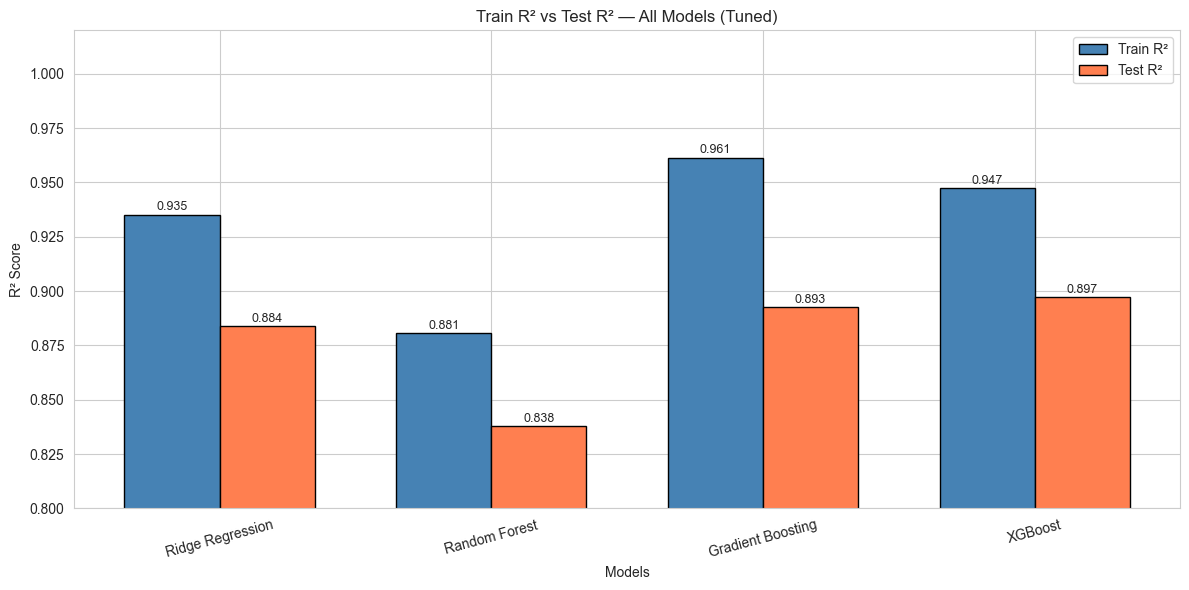

✅ Plot 1 saved


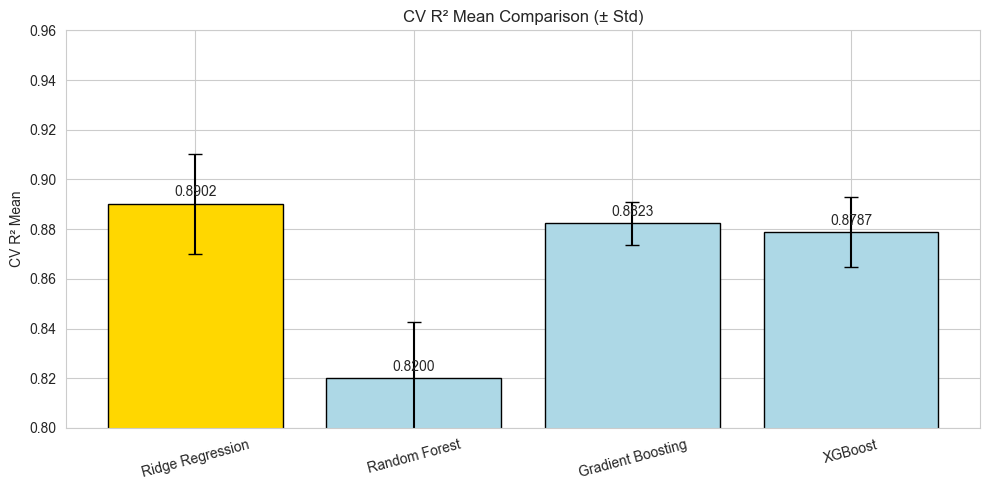

✅ Plot 2 saved


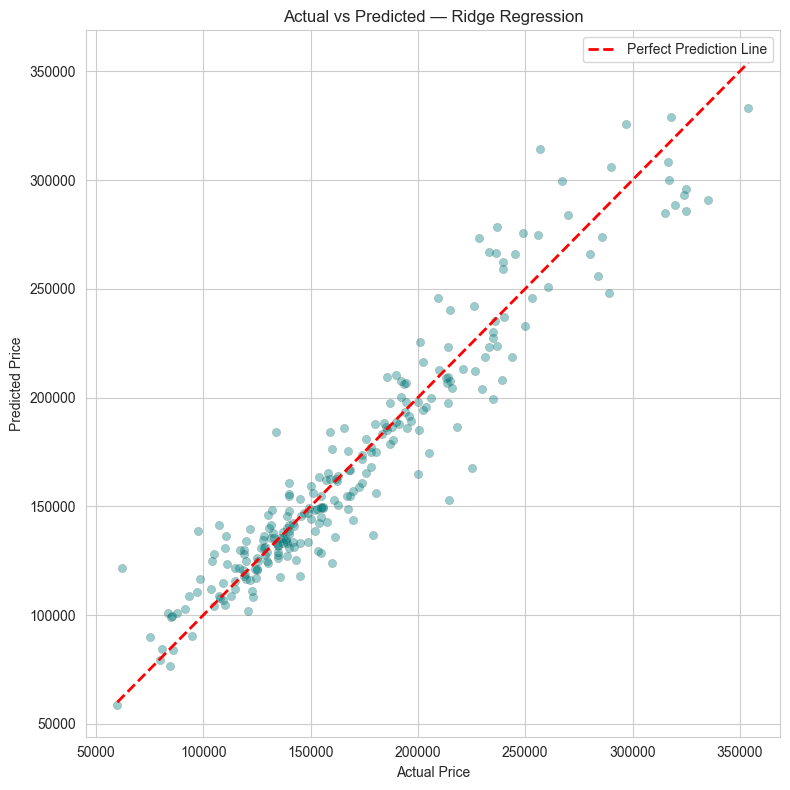

✅ Plot 3 saved


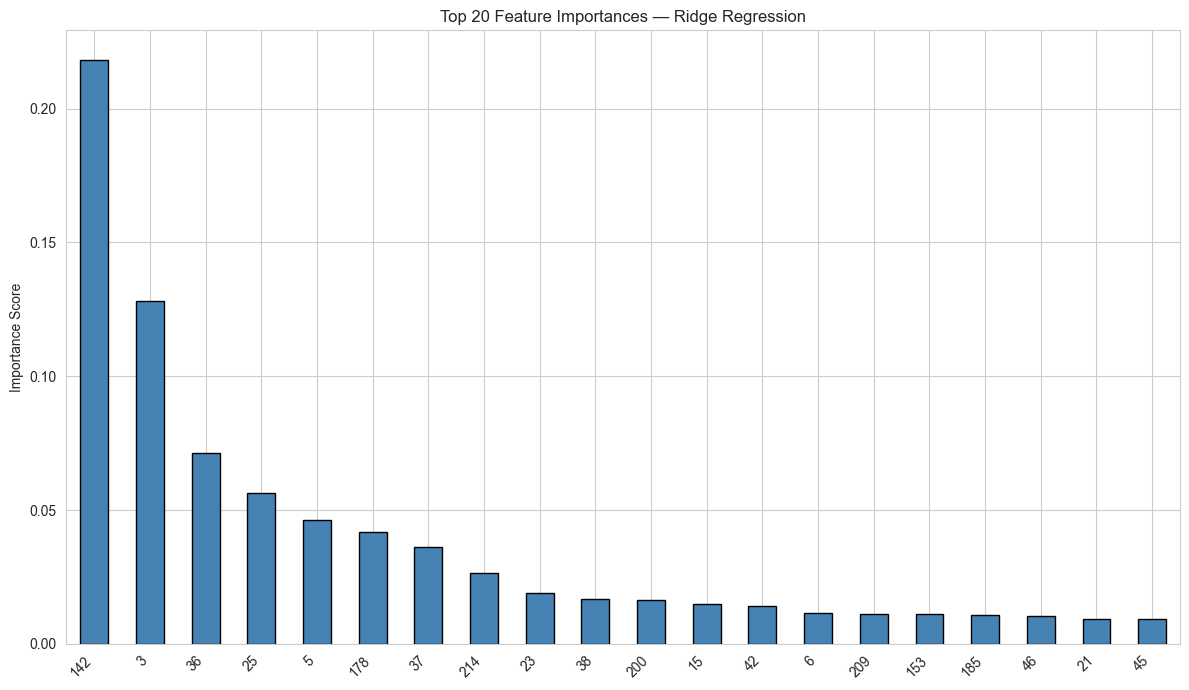

✅ Plot 4 saved

✅ All 4 plots saved in 'plots/' folder!


In [54]:
import matplotlib.pyplot as plt
import numpy as np

# =============================================
# PLOT 1: Train vs Test R² Comparison
# =============================================

model_names = list(tuned_results.keys())
train_r2_vals = [tuned_results[m]['Train R²'] for m in model_names]
test_r2_vals  = [tuned_results[m]['Test R²']  for m in model_names]

x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, train_r2_vals, width, label='Train R²',
               color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, test_r2_vals,  width, label='Test R²',
               color='coral',     edgecolor='black')

ax.set_xlabel("Models")
ax.set_ylabel("R² Score")
ax.set_title("Train R² vs Test R² — All Models (Tuned)")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15)
ax.legend()
ax.set_ylim(0.8, 1.02)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("plots/13_train_vs_test_r2.png", dpi=150)
plt.show()
print("✅ Plot 1 saved")

# =============================================
# PLOT 2: CV R² Comparison
# =============================================

cv_means = [cv_results[m]['CV R² Mean'] for m in model_names]
cv_stds  = [cv_results[m]['CV R² Std']  for m in model_names]
colors   = ['gold' if m == best_model_name else 'lightblue' for m in model_names]

plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, cv_means, yerr=cv_stds, color=colors,
               edgecolor='black', capsize=5)
plt.title("CV R² Mean Comparison (± Std)")
plt.ylabel("CV R² Mean")
plt.xticks(rotation=15)
plt.ylim(0.8, 0.96)

for bar, val in zip(bars, cv_means):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig("plots/14_cv_r2_comparison.png", dpi=150)
plt.show()
print("✅ Plot 2 saved")

# =============================================
# PLOT 3: Actual vs Predicted — Best Model
# =============================================

best_model_obj = xgb.best_estimator_
y_pred_best    = best_model_obj.predict(X_test)

actual_price    = np.expm1(y_test)
predicted_price = np.expm1(y_pred_best)

plt.figure(figsize=(8, 8))
plt.scatter(actual_price, predicted_price,
            alpha=0.4, color='teal', edgecolors='k', linewidths=0.2)
plt.plot(
    [actual_price.min(), actual_price.max()],
    [actual_price.min(), actual_price.max()],
    'r--', linewidth=2, label='Perfect Prediction Line'
)
plt.title(f"Actual vs Predicted — {best_model_name}")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.tight_layout()
plt.savefig("plots/15_actual_vs_predicted.png", dpi=150)
plt.show()
print("✅ Plot 3 saved")

# =============================================
# PLOT 4: Feature Importance — Best Model
# =============================================

feature_names = best_model_obj.get_booster().feature_names

feat_imp = pd.Series(
    best_model_obj.feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(20)

feat_imp = pd.Series(
    best_model_obj.feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 7))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title(f"Top 20 Feature Importances — {best_model_name}")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("plots/16_feature_importance.png", dpi=150)
plt.show()
print("✅ Plot 4 saved")

print("\n✅ All 4 plots saved in 'plots/' folder!")

# pkl file save

In [57]:
import joblib
import os

os.makedirs("models", exist_ok=True)

# =============================================
# BEST MODEL — Ridge Regression
# =============================================
best_model_obj = ridge.best_estimator_

# --- Save Best Model ---
joblib.dump(best_model_obj, 'models/best_model_Ridge_Regression.pkl')
print("✅ Best model saved    : models/best_model_Ridge_Regression.pkl")

# --- Save Scaler ---
joblib.dump(scaler, 'models/scaler.pkl')
print("✅ Scaler saved        : models/scaler.pkl")

# --- Save Feature Names ---
# FIX Issue 3: Ridge has no get_booster() — that's XGBoost only
# Ridge is a linear model — feature names are just column names before scaling
feature_names = list(X.drop(['SalePrice'], axis=1, errors='ignore').columns)
joblib.dump(feature_names, 'models/feature_names.pkl')
print("✅ Feature names saved : models/feature_names.pkl")
print(f"   Total features     : {len(feature_names)}")

# =============================================
# VERIFY — Load and test
# =============================================
loaded_model = joblib.load('models/best_model_Ridge_Regression.pkl')

# FIX Issue 4: Ridge was trained on SCALED data — must use X_test_scaled
sample_pred     = loaded_model.predict(X_test_scaled)   # ✅ scaled data
sample_actual   = np.expm1(y_test.values[:5])
sample_pred_inv = np.expm1(sample_pred[:5])

print("\n📊 Verification — Sample Predictions:")
print(f"{'Actual Price':<20} {'Predicted Price':<20}")
print("-" * 40)
for a, p in zip(sample_actual, sample_pred_inv):
    print(f"{a:<20,.0f} {p:<20,.0f}")

print("\n🎉 Pipeline Complete! Model ready for deployment!")

✅ Best model saved    : models/best_model_Ridge_Regression.pkl
✅ Scaler saved        : models/scaler.pkl
✅ Feature names saved : models/feature_names.pkl
   Total features     : 80

📊 Verification — Sample Predictions:
Actual Price         Predicted Price     
----------------------------------------
170,000              147,914             
178,000              158,210             
235,000              235,175             
139,000              132,349             
110,000              149,241             

🎉 Pipeline Complete! Model ready for deployment!
